    claude --resume "fix-bffg-importance-weight"

# Two-epoch coalescent inference with BFFG

Backward-Filtering Forward-Guiding (BFFG) inference of a two-epoch coalescent model from sparse single-mutation observations.

**Model.** Block coalescent with $n$ samples and per-pair coalescence rate $\theta_e$ in epoch $e \in \{1,2\}$, with epoch boundary $\tau$ assumed known. The time-inhomogeneity is encoded **topologically**: `g_epochs = g_cont.add_epoch(time=τ)` augments the state vector with an `epoch` slot and adds deterministic epoch-transition edges between sister vertices. The resulting graph is a **standard parameterized DTMC** with parameter vector $[\theta_1, \theta_2, r_{\mathrm{trans}}, \mu]$:

- $\theta_1, \theta_2$ — per-epoch coalescence rates (free parameters).
- $r_{\mathrm{trans}}$ — epoch-transition rate, fixed to 1 to preserve deterministic timing.
- $\mu$ — mutation rate, fixed by the data-generation model.

**Observation model.** At each locus we observe one mutation type $j \in \{1,\dots,n-1\}$ (singleton/doubleton/...). Terminal "t-vertices" in the joint probability graph represent the SFS bins.

**BFFG.** Paths sampled from the joint graph traverse coalescence, mutation, AND epoch-crossing edges as discrete state transitions — **no time integrals are needed**. The IS weight from a homogeneous proposal $[\theta_0, \theta_0, 1, \mu]$ to a target $[\theta_1, \theta_2, 1, \mu]$ is a per-edge density ratio plus an inverse-guiding correction (because `sample_path_conditioned` is an h-guided forward sampler, not a true Doob h-transform).

**Inference.** MCMC over $(\theta_1, \theta_2)$ in two ways:

1. A **manual, transparent** BFFG log-likelihood plumbed into `MCMC(log_prob_fn=...)`. Easy to introspect for diagnostics — used through section 9.
2. The **package's `bffg_log_prob(..., return_model=True)`** plumbed into `MCMC(model=..., likelihood_correction=...)`. Section 10.

In [1]:
from phasic import (
    Graph, MCMC, GaussPrior, with_ipv,
    StateIndexer, Property,
)

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# Optional VSCode notebook theme — comment out if not running in VSCode.
try:
    from vscodenb import set_vscode_theme
    set_vscode_theme()
except ImportError:
    pass

np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Build the time-inhomogeneous coalescent graph

`Graph(coal_callback, indexer=indexer)` builds a homogeneous coalescent. Wrapping it in `add_epoch(time=τ)` returns a new graph in which:

- The state vector is extended with an `epoch` slot.
- Vertices in epoch 1 are duplicated as sister vertices in epoch 2.
- Each non-absorbing epoch-1 vertex gets a deterministic epoch-transition edge to its sister, with rate `stop_probability(τ)/accumulated_occupancy(τ)` placed in a dedicated coefficient slot.

The parameter vector becomes $[\theta_1, \theta_2, r_{\mathrm{trans}}]$. Coalescence edges in epoch 1 use slot 0, in epoch 2 use slot 1, and epoch-transition edges use slot 2 (fixed to 1 to preserve the deterministic timing).

In [2]:
from itertools import combinations_with_replacement

N_SAMPLES = 5
EPOCH_BOUNDARY = 0.5
TRUE_THETA1 = 2.0
TRUE_THETA2 = 0.5
MUTATION_RATE = 0.01
REWARD_LIMIT = 5      # cap on mutations per locus the joint graph tracks

# Indexer over the lineage state — one Property: descendants count per block.
indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=N_SAMPLES)],
)
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = N_SAMPLES  # start with N_SAMPLES singletons


@with_ipv(ipv)
def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions


g_cont = Graph(coal_callback, indexer=indexer)
print(f"Continuous (homogeneous) coalescent: {g_cont.vertices_length()} vertices, "
      f"state_length {g_cont.state_length()}, param_length {g_cont.param_length()}")

Continuous (homogeneous) coalescent: 8 vertices, state_length 5, param_length 1


## 2. Add the epoch transition and build the joint probability graph

Layering `joint_prob_graph` on top of `g_epochs` adds a fourth parameter slot for the mutation rate $\mu$. The full parameter vector is $[\theta_1, \theta_2, r_{\mathrm{trans}}=1, \mu]$.

In [3]:
g_epochs = g_cont.add_epoch(time=EPOCH_BOUNDARY)
print(f"g_epochs: {g_epochs.vertices_length()} vertices, "
      f"state_length {g_epochs.state_length()}, param_length {g_epochs.param_length()}")

# Build the joint probability graph layered on top of g_epochs.
# joint_prob_graph adds the mutation-rate slot at the end of the parameter vector.
jg_cont = g_epochs.joint_prob_graph(
    indexer,
    mutation_rate=MUTATION_RATE,
    reward_limit=REWARD_LIMIT,
)
print(f"jg_cont:  {jg_cont.vertices_length()} vertices, "
      f"state_length {jg_cont.state_length()}, param_length {jg_cont.param_length()}")
print(f"Parameter vector layout: [theta_epoch1, theta_epoch2, r_trans=1, mu]")

g_epochs: 15 vertices, state_length 6, param_length 3
jg_cont:  6208 vertices, state_length 11, param_length 4
Parameter vector layout: [theta_epoch1, theta_epoch2, r_trans=1, mu]


In [4]:
# Truth and proposal parameter vectors (4 entries: [theta1, theta2, r_trans, mu])
true_theta = np.array([TRUE_THETA1, TRUE_THETA2, 1.0, MUTATION_RATE])

THETA_0 = 1.0   # homogeneous proposal rate (same for both epoch slots)
theta_proposal = np.array([THETA_0, THETA_0, 1.0, MUTATION_RATE])

# Set proposal weights and read out the joint probability table to identify t-vertices.
jg_cont.update_weights(theta_proposal.tolist())
jpt = jg_cont.joint_prob_table()
print(jpt)

term_state_cols = jpt.columns[:-1]
print("\nReward state columns:", list(term_state_cols))

# Map mutation type (1..N_SAMPLES-1) → t-vertex index. Each row of the joint_prob_table
# whose reward state has sum == 1 is a single-mutation t-vertex; the column whose value
# is 1 indicates which descendants count was mutated.
mut_type_to_terminal = {}
for tv in jpt.index:
    state_row = jpt.loc[tv, term_state_cols].to_numpy(dtype=int)
    if state_row.sum() == 1:
        col_idx = int(np.argmax(state_row))
        col_name = term_state_cols[col_idx]
        # column name is e.g. 'descendants_1' or 'lineages_descendants_1'; trailing int is the type
        try:
            j = int(col_name.split('_')[-1])
        except ValueError:
            j = col_idx + 1
        mut_type_to_terminal[j] = int(tv)
term_to_type = {v: k for k, v in mut_type_to_terminal.items()}
valid_t_vertices = set(int(tv) for tv in jpt.index)
print("Mutation type → t-vertex index:", mut_type_to_terminal)

                descendants_1  descendants_2  descendants_3  descendants_4  \
t_vertex_index                                                               
28                          0              0              0              0   
61                          0              0              0              0   
64                          0              1              0              0   
67                          0              0              1              0   
71                          1              0              0              0   
...                       ...            ...            ...            ...   
6199                        5              5              4              5   
6200                        5              5              5              4   
6202                        4              5              5              5   
6203                        5              5              5              5   
6204                        5              5              5     

## 3. Proposal vs target parameter vectors

We use a **homogeneous proposal** $[\theta_0, \theta_0, 1, \mu]$ — the same rate in both epoch slots — and re-weight to the inhomogeneous target $[\theta_1, \theta_2, 1, \mu]$. With this design `theta_proposal` and `theta_target` differ only in the first two entries; the epoch-transition rate and mutation rate are shared.

This means we don't need any "piecewise rate function" at all: time-inhomogeneity is encoded as a state transition in the graph topology, and target/proposal both consume **constant** parameter vectors.

In [5]:
# All constants (EPOCH_BOUNDARY, TRUE_THETA1, TRUE_THETA2, MUTATION_RATE, REWARD_LIMIT)
# and the parameter vectors (true_theta, theta_proposal) were defined above.
print(f"true_theta:     {true_theta}")
print(f"theta_proposal: {theta_proposal}")

true_theta:     [2.   0.5  1.   0.01]
theta_proposal: [1.   1.   1.   0.01]


## 4. Importance weight for guided proposal paths

`Graph.sample_path_conditioned([t_v])` is a **guided forward sampler**: at each transient vertex it picks the next edge with probability $\propto w_e \cdot h(\mathrm{child}_e)$ where $h = $ `backward_probabilities([t_v])`. Sojourn times come from $\mathrm{Exp}(R_v)$ with the **stored** edge weights.

Because `joint_prob_graph` sets `was_dph=True`, `update_weights` normalizes the stored weights to sum to 1 per vertex — so the C sampler's `entry_times` come from $\mathrm{Exp}(1)$ and are not physical sojourn times. We **resample physical sojourn times** $\Delta t \sim \mathrm{Exp}(R_v^{\mathrm{prop}})$ at each transient vertex, with $R_v^{\mathrm{prop}} = \sum_e \mathbf{c}_e \cdot \boldsymbol{\theta}_{\mathrm{prop}}$ from the raw edge coefficients.

Per transient step the IS weight (target unconditional / guided proposal) is

$$
\log w_{\mathrm{step}} \;=\; \underbrace{\log w_e^{\mathrm{tgt}} - R_v^{\mathrm{tgt}}\,\Delta t}_{\text{target step density}}
\underbrace{- \log R_v^{\mathrm{prop}} + R_v^{\mathrm{prop}}\,\Delta t}_{\text{cancel proposal sojourn}}
\underbrace{- \log w_e^{\mathrm{prop}}}_{\text{cancel proposal jump weight}}
\underbrace{- \log h(\mathrm{child}_e) + \log\!\sum_{e'} w_{e'}^{\mathrm{prop}}\,h(\mathrm{child}_{e'})}_{\text{undo guided edge prob}}
$$

with $w_e^{\mathrm{tgt}} = \mathbf{c}_e \cdot \boldsymbol{\theta}_{\mathrm{tgt}}$ and similarly for the proposal. **No time integrals, no piecewise-rate function** — the time-inhomogeneity is in the graph topology, not in a $\theta(t)$.

**Identity check.** When $\boldsymbol{\theta}_{\mathrm{tgt}} = \boldsymbol{\theta}_{\mathrm{prop}}$, $w_e^{\mathrm{tgt}} = w_e^{\mathrm{prop}}$ and $R_v^{\mathrm{tgt}} = R_v^{\mathrm{prop}}$, so every step contribution simplifies via the backward equation $\sum_e w_e h(\mathrm{child}_e) = R_v h(v)$ to $\log h(v_k) - \log h(\mathrm{child}_e)$, telescoping across the path to $\log h(v_{\mathrm{first}})$ — a path-independent constant. So $\mathrm{var}(\log w) = 0$ at identity, and $E[\exp(\log w)] = h_{\mathrm{tgt}}(v_0)$ in general.

The pseudo-marginal estimator is $\log P(s\mid\boldsymbol{\theta}_{\mathrm{target}}) \approx \log E_{\mathrm{prop}}[\exp(\log w)]$ (up to a path-independent constant from the start vertex which cancels in MCMC ratios).

In [6]:
from scipy.special import logsumexp as scipy_logsumexp


def vertex_edge_data(jg, n_params):
    """Cache per-vertex parameterized-edge tables for a joint graph.

    Returns ``{vertex_idx: (children, coeff_matrix)}`` for transient vertices.
    Pads ragged edge_states (the start vertex's IPV edges have length-1 edge_state).
    """
    out = {}
    for vi, v in enumerate(jg.vertices()):
        if v.edges_length() == 0:
            continue
        edges = v.parameterized_edges()
        if not edges:
            continue
        rows = []
        for e in edges:
            es = list(e.edge_state(n_params))
            if len(es) < n_params:
                es = es + [0.0] * (n_params - len(es))
            rows.append(es[:n_params])
        coeffs = np.array(rows, dtype=float)
        if coeffs.ndim == 1:
            coeffs = coeffs.reshape(1, -1)
        children = np.array([e.to().index() for e in edges], dtype=int)
        out[vi] = (children, coeffs)
    return out


def find_trash_vertices(jg):
    """Identify the trash_vertex / trash_loop_vertex pair: all-zero state, edges_length>0,
    excluding the starting vertex (which also has all-zero state)."""
    trash = set()
    states = jg.states()
    start = jg.starting_vertex().index()
    for vi, v in enumerate(jg.vertices()):
        if vi == start or v.edges_length() == 0:
            continue
        if int(states[vi].sum()) == 0:
            trash.add(vi)
    return trash


def log_iw_corrected(jg, path, theta_target, theta_prop, h, t_vertex,
                     edge_cache, rng):
    """Importance weight for a path from ``sample_path_conditioned([t_vertex])`` on
    a parameterized DTMC built via ``joint_prob_graph``. Re-samples physical sojourn
    times Δt ~ Exp(R_v^prop) (since the stored DTMC weights are normalized) and
    evaluates the IS weight against the target unconditional CTMC.

    Both ``theta_target`` and ``theta_prop`` are full graph-level parameter vectors
    of length ``jg.param_length()``. Time-inhomogeneity is encoded in the graph
    topology (via ``add_epoch``), so this formula has no time integrals.

    Returns ``log_w`` such that ``E_{p_prop}[exp(log_w)] = h_target(v_start)``.
    """
    indices = path['vertex_indices']
    log_w = 0.0
    for step in range(1, len(indices) - 1):
        v_idx = int(indices[step])
        if v_idx == t_vertex:
            break
        if v_idx not in edge_cache:
            break
        children, coeffs = edge_cache[v_idx]
        h_child = h[children]

        w_prop = coeffs @ theta_prop
        w_tgt = coeffs @ theta_target
        R_prop = w_prop.sum()
        R_tgt = w_tgt.sum()
        if R_prop <= 0:
            return -np.inf

        valid = (h_child > 0) & (w_prop > 0)
        log_Z_prop = scipy_logsumexp(np.log(w_prop[valid]) + np.log(h_child[valid]))

        # taken edge: child = indices[step + 1]
        next_v = int(indices[step + 1])
        e_idx_arr = np.where(children == next_v)[0]
        if e_idx_arr.size == 0:
            break
        e_idx = int(e_idx_arr[0])

        # Physical sojourn time, Exp(R_prop)
        u = rng.uniform()
        dt = -np.log(u + 1e-30) / R_prop

        if w_tgt[e_idx] <= 0 or w_prop[e_idx] <= 0 or h_child[e_idx] <= 0:
            return -np.inf

        log_w += (
            np.log(w_tgt[e_idx]) - R_tgt * dt                       # target step density
            - np.log(R_prop) + R_prop * dt                          # cancel proposal sojourn density
            - np.log(w_prop[e_idx])                                 # cancel proposal jump weight
            - np.log(h_child[e_idx]) + log_Z_prop                   # undo guided edge prob
        )
    return log_w


# Pre-compute edge cache, h(v) for each candidate t-vertex, trash vertices.
N_PARAMS = jg_cont.param_length()
jg_cont.update_weights(theta_proposal.tolist())
edge_cache_cont = vertex_edge_data(jg_cont, n_params=N_PARAMS)
trash_vertices = find_trash_vertices(jg_cont)
h_per_target = {tv: jg_cont.backward_probabilities([tv]) for tv in valid_t_vertices}
v_start_idx = jg_cont.starting_vertex().index()
print(f"N_PARAMS = {N_PARAMS}, v_start = {v_start_idx}, trash vertices = {trash_vertices}")

N_PARAMS = 4, v_start = 0, trash vertices = {6205, 6206}


In [7]:
# --- Sanity checks for log_iw_corrected ---

test_rng = np.random.default_rng(1)
target_v = mut_type_to_terminal[1]   # singleton t-vertex
h_tv_prop = h_per_target[target_v]

# Test 1 (identity). With target = proposal, log_w must be a path-independent constant
# equal to log h(v_first), and E[exp(log_w)] = h_proposal(v_start).
log_ws_id = []
for _ in range(300):
    p = jg_cont.sample_path_conditioned([target_v])
    log_ws_id.append(log_iw_corrected(jg_cont, p, theta_proposal, theta_proposal,
                                       h_tv_prop, target_v, edge_cache_cont, test_rng))
log_ws_id = np.array(log_ws_id)
print("Identity test (target = proposal):")
print(f"  var(log_w)  = {np.var(log_ws_id):.3e}    (must be ≈ 0)")
print(f"  mean(log_w) = {np.mean(log_ws_id):.6f}    expected log h(v0) = {np.log(h_tv_prop[v_start_idx]):.6f}")
print(f"  E[exp(log_w)] = {np.mean(np.exp(log_ws_id)):.6f}    h_proposal(v0) = {h_tv_prop[v_start_idx]:.6f}")

# Test 2 (homogeneous perturbation in slots 0 and 1). With target = (1+ε)·θ_0 in both
# epoch slots, the exact target reach probability is read from a re-built joint graph.
EPS = 0.05
theta_pert = theta_proposal.copy()
theta_pert[0] = THETA_0 * (1 + EPS)
theta_pert[1] = THETA_0 * (1 + EPS)

jg_test = g_epochs.joint_prob_graph(indexer, mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT)
jg_test.update_weights(theta_pert.tolist())
h_tgt_test = jg_test.backward_probabilities([target_v])
expected_h_tgt = float(h_tgt_test[v_start_idx])
jg_cont.update_weights(theta_proposal.tolist())   # restore proposal weights on jg_cont

print(f"\nPerturbation test (target = θ_0·(1+{EPS}) in both epoch slots):")
print(f"  expected E[exp(log_w)] = h_target(v0) = {expected_h_tgt:.6f}")

log_ws_pert = []
N_TEST = 5000
for _ in range(N_TEST):
    p = jg_cont.sample_path_conditioned([target_v])
    log_ws_pert.append(log_iw_corrected(jg_cont, p, theta_pert, theta_proposal,
                                         h_tv_prop, target_v, edge_cache_cont, test_rng))
log_ws_pert = np.array(log_ws_pert)
m = log_ws_pert.max()
empirical = np.mean(np.exp(log_ws_pert - m)) * np.exp(m)
se = np.std(np.exp(log_ws_pert - m)) * np.exp(m) / np.sqrt(N_TEST)
print(f"  empirical = {empirical:.6f} ± {se:.6f}")
print(f"  agreement: {abs(empirical - expected_h_tgt) / se:.2f} SE")

Identity test (target = proposal):
  var(log_w)  = 3.871e-30    (must be ≈ 0)
  mean(log_w) = -8.572163    expected log h(v0) = -8.572163
  E[exp(log_w)] = 0.000189    h_proposal(v0) = 0.000189

Perturbation test (target = θ_0·(1+0.05) in both epoch slots):
  expected E[exp(log_w)] = h_target(v0) = 0.000179
  empirical = 0.000179 ± 0.000000
  agreement: 0.17 SE


## 5. Simulate observations under the true two-epoch model

Forward Gillespie simulation on the joint graph using the **un-normalized** edge rates (`coefficients @ true_theta`). Because the time-inhomogeneity is encoded as discrete state transitions in the graph, no per-step boundary handling is needed — paths naturally cross epochs through their dedicated transition edges.

In [8]:
def gillespie_one(edge_cache, start_idx, theta, rng,
                  valid_t_vertices, trash_vertices, max_steps=400):
    """Forward-simulate one path on the joint graph using raw rates ``coeffs @ theta``.

    Stops when (a) hits absorbing (no edges), (b) enters the trash loop, or
    (c) exceeds max_steps. Returns the last visited t-vertex (or None if no
    t-vertex was ever reached).
    """
    v = start_idx
    last_tv = None
    for _ in range(max_steps):
        if v in valid_t_vertices:
            last_tv = v
        if v not in edge_cache:
            break
        if v in trash_vertices:
            break
        children, coeffs = edge_cache[v]
        rates = coeffs @ theta
        total = rates.sum()
        if total <= 0:
            break
        u = rng.uniform()
        cum = 0.0
        idx = len(children) - 1
        for j in range(len(children)):
            cum += rates[j] / total
            if u < cum:
                idx = j
                break
        v = int(children[idx])
    return last_tv


def simulate_observation(theta_target, edge_cache, start_idx,
                         valid_t_vertices, trash_vertices, rng, max_tries=500):
    """Direct Gillespie forward simulation. Returns the observed t-vertex index."""
    for _ in range(max_tries):
        tv = gillespie_one(edge_cache, start_idx, theta_target, rng,
                           valid_t_vertices, trash_vertices)
        if tv is not None:
            return tv
    raise RuntimeError("Forward simulation never reached a valid t-vertex.")


N_LOCI = 1000
sim_rng = np.random.default_rng(101)
observed_data = np.empty(N_LOCI, dtype=np.int32)
for locus in range(N_LOCI):
    observed_data[locus] = simulate_observation(
        true_theta, edge_cache_cont, v_start_idx,
        valid_t_vertices, trash_vertices, sim_rng,
    )

uniq, counts = np.unique(observed_data, return_counts=True)
print(f"observed t-vertex counts: {dict(zip(uniq.tolist(), counts.tolist()))}")
mut_type_counts = np.zeros(N_SAMPLES - 1, dtype=int)
for v in observed_data:
    j = term_to_type.get(int(v))
    if j is not None and 1 <= j <= N_SAMPLES - 1:
        mut_type_counts[j - 1] += 1
print(f"SFS counts (singleton, doubleton, ...): {mut_type_counts}")

observed t-vertex counts: {28: 186, 61: 814}
SFS counts (singleton, doubleton, ...): [0 0 0 0]


## 6. BFFG log-likelihood

For each locus, sample $M$ paths conditioned on the observed t-vertex and average $\exp(\log w_m)$. The sum over loci of $\log\hat E[w]$ is an estimator of the log-likelihood up to a path-independent constant from the start vertex which cancels in MCMC ratios.

The MCMC parameter is just $(\theta_1, \theta_2)$; we expand it into the full graph parameter vector $[\theta_1, \theta_2, 1, \mu]$ inside `bffg_log_likelihood`.

In [9]:
bffg_lik_rng = np.random.default_rng(303)


def bffg_log_likelihood(theta_mcmc, observed_data, n_paths=50,
                        return_diagnostics=False, rng=None):
    """log-likelihood estimate for the 2D MCMC parameter [theta1, theta2].

    Internally expands to the full graph parameter vector [theta1, theta2, 1, mu].
    """
    if rng is None:
        rng = bffg_lik_rng
    theta_full = np.array([float(theta_mcmc[0]), float(theta_mcmc[1]),
                           1.0, MUTATION_RATE])
    total = 0.0
    diag = {'log_weights_per_locus': [], 'ess_per_locus': []}
    for locus in range(len(observed_data)):
        target_v = int(observed_data[locus])
        h_tv = h_per_target[target_v]
        log_weights = np.empty(n_paths)
        for m in range(n_paths):
            path = jg_cont.sample_path_conditioned([target_v])
            log_weights[m] = log_iw_corrected(
                jg_cont, path, theta_full, theta_proposal,
                h_tv, target_v, edge_cache_cont, rng,
            )
        log_mean_w = float(scipy_logsumexp(log_weights) - np.log(n_paths))
        total += log_mean_w
        if return_diagnostics:
            diag['log_weights_per_locus'].append(log_weights)
            w = np.exp(log_weights - log_weights.max())
            diag['ess_per_locus'].append((w.sum())**2 / (w**2).sum())
    return (total, diag) if return_diagnostics else total

## 6b. BFFG correction: smooth model A → step-wise model B

The path-level IS estimator above weighted from a homogeneous proposal to the same homogeneous target. Here we do **proper BFFG** for model-class extension: phasic natively handles model A (homogeneous on the augmented epoch state space, smooth in wall-time), but the user actually wants posteriors under model B (piecewise-constant rate $\theta(t)$ in wall-time, hard switch at $\tau$).

**Models:**

- **Model A** (smooth, native): the augmented graph `g_epochs` evaluated as a homogeneous CTMC. At any vertex $v$ with epoch slot $e_v$:
   - coalescence rate $= \theta_{e_v} \cdot \binom{k_v}{2}$
   - mutation rate $= \mu \cdot k_v$
   - epoch-transition rate (only at $e_v=0$ vertices) $= r_{\text{trans},v}$, computed by `add_epoch` so A's marginal moments match B's.

- **Model B** (true target, NOT native): a CTMC on the **base** state space with time-varying rate
   - coalescence rate at wall-time $t$ = $\theta_B(t) \cdot \binom{k,2}$, where $\theta_B(t)=\theta_1$ if $t<\tau$ else $\theta_2$.
   - mutation rate = $\mu \cdot k$
   - no epoch-transition events (the rate just switches at $\tau$).

**Per-path Radon-Nikodym derivative.** A path sampled under A has a sequence of (state, wall-time) pairs. Project to the base state by dropping the epoch coordinate to get the kind of path B generates. The log-density of B w.r.t. A on this path is

$$
\log \frac{dP_B}{dP_A}(\pi) \;=\; \underbrace{\sum_{\text{coal. events } k} [\log \theta_B(t_k) - \log \theta_{e_k}]}_{\text{rate-of-taken-edge ratio}}
\;-\; \underbrace{\sum_{\text{sojourns } s} (\theta_B^{\text{integrated}}(s) - \theta_{e_s}\cdot|s|) \cdot \binom{k_s}{2}}_{\text{coal. survival ratio}}
\;+\; \underbrace{\sum_{\text{epoch-trans events}} (-\log r_{\text{trans},v})}_{\text{A has these, B doesn't}}
\;-\; \underbrace{\sum_{\text{sojourns} s, e_s=0} (-r_{\text{trans},v_s}\cdot|s|)}_{\text{A's epoch-trans survival}}
$$

where $\theta_B^{\text{integrated}}(s) = \int_s \theta_B(t)\,dt$ is the time-integrated B-rate over sojourn $s$, splitting at $\tau$ if the sojourn straddles. Mutation rates cancel because $\mu$ is the same in A and B.

**Combined likelihood:** for each locus $i$, the BFFG estimator is

$$
\hat L_B(s_i \mid \theta) \;=\; \frac{1}{n_{\text{paths}}} \sum_{m=1}^{n_{\text{paths}}} P_A(s_i\mid\theta) \cdot \exp\!\big(\log dP_B/dP_A(\pi_m)\big)
$$
where $\pi_m$ is sampled under A's conditional distribution given absorption at $s_i$. The total log-likelihood is $\sum_i \log \hat L_B(s_i\mid\theta)$.

This estimator is **unbiased**: $E_A[\hat L_B] = P_B(s_i\mid\theta)$ exactly. As $n_{\text{paths}}\to\infty$, the MCMC posterior converges to the true posterior under model B.

**Future optimization (not implemented now):** the per-path log $w$ can be replaced by a closed-form expression in the conditional expected sojourn times $E_A[\text{occ}_v\mid s_i, \theta]$. That would eliminate the path-sampling Monte Carlo variance. The hook is the function `compute_path_log_w` below — replacing its body with a deterministic formula evaluated at decoded occupancies is the only change needed.

In [10]:
# Setup for BFFG model A -> model B correction.
#
# Layout of jg_cont state vector: [block_1..block_5, epoch, reward_1..reward_5]
#   - state[0:N_SAMPLES] = block counts (sizes 1..N)
#   - state[N_SAMPLES] = epoch (0 or 1)
#   - state[N_SAMPLES+1:2*N_SAMPLES+1] = reward counts (mutation tallies for sizes 1..N)
#
# Edge coefficient layout: [c_theta1, c_theta2, c_r_trans, c_mu]  (param_length=4 on jg_cont)
#   - coalescence in epoch 0: [pair_count, 0, 0, 0]
#   - coalescence in epoch 1: [0, pair_count, 0, 0]
#   - epoch-transition (epoch 0 -> epoch 1): [0, 0, r_trans_v, 0]
#   - mutation:                 [0, 0, 0, branch_count]

EPOCH_STATE_IDX = N_SAMPLES                  # = 5; from g_epochs._epoch_state_index
BLOCK_SLICE = slice(0, N_SAMPLES)            # indices 0..4
REWARD_SLICE = slice(N_SAMPLES + 1, 2 * N_SAMPLES + 1)  # indices 6..10

# Sanity: verify the layout on a transient vertex and on the start vertex
v_check_state = jg_cont.states()[1]   # v1 = first transient state with all singletons
print(f"v1 state: {list(int(x) for x in v_check_state)}")
print(f"  blocks (state[{BLOCK_SLICE}]): {list(int(x) for x in v_check_state[BLOCK_SLICE])}")
print(f"  epoch (state[{EPOCH_STATE_IDX}]): {int(v_check_state[EPOCH_STATE_IDX])}")
print(f"  rewards (state[{REWARD_SLICE}]): {list(int(x) for x in v_check_state[REWARD_SLICE])}")

# Per-vertex epoch index, block-pair-count, and edge data
jg_states = jg_cont.states()
v_epoch_jg = jg_states[:, EPOCH_STATE_IDX].astype(int)         # epoch label per jg vertex
n_lin_jg = jg_states[:, BLOCK_SLICE].sum(axis=1).astype(int)   # k_v per jg vertex
pair_count_jg = n_lin_jg * (n_lin_jg - 1) // 2                  # C(k_v, 2) per jg vertex

# Use the existing edge_cache_cont if available, otherwise build one
if 'edge_cache_cont' not in dir():
    edge_cache_cont = vertex_edge_data(jg_cont, n_params=jg_cont.param_length())
if 'trash_vertices' not in dir():
    trash_vertices = find_trash_vertices(jg_cont)

print(f"\n# of transient vertices in epoch 0: {((v_epoch_jg == 0) & (n_lin_jg > 0)).sum()}")
print(f"# of transient vertices in epoch 1: {((v_epoch_jg == 1) & (n_lin_jg > 0)).sum()}")
print(f"trash_vertices: {trash_vertices}")

v1 state: [5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  blocks (state[slice(0, 5, None)]): [5, 0, 0, 0, 0]
  epoch (state[5]): 0
  rewards (state[slice(6, 11, None)]): [0, 0, 0, 0, 0]

# of transient vertices in epoch 0: 3102
# of transient vertices in epoch 1: 3102
trash_vertices: {6205, 6206}


In [11]:
def compute_path_log_w(path, theta_full, rng,
                       v_epoch=v_epoch_jg, pair_count=pair_count_jg, n_lin=n_lin_jg,
                       edge_cache=edge_cache_cont, trash_vertices=trash_vertices,
                       epoch_boundary=EPOCH_BOUNDARY):
    """Closed-form per-path log [dP_B / dP_A] for one path sampled by sample_path_conditioned
    on jg_cont (model A's joint graph).

    We **resample** physical sojourn times Δt ~ Exp(R_v_raw) per transient vertex (since
    jg_cont is a normalized DTMC and entry_times from the C sampler are not physical).

    theta_full = [θ_1, θ_2, r_trans_global=1, μ] is the GRAPH-level parameter vector.
        θ_1, θ_2 also serve as model B's per-epoch rates.
    """
    indices = path['vertex_indices']
    if len(indices) < 3:
        return 0.0
    log_w = 0.0
    cumulative_t = 0.0
    theta_1, theta_2 = float(theta_full[0]), float(theta_full[1])
    mu = float(theta_full[3])

    for step in range(1, len(indices) - 1):
        v_idx = int(indices[step])
        if v_idx in trash_vertices:
            break
        if v_idx not in edge_cache:
            break
        children, coeffs = edge_cache[v_idx]
        next_v = int(indices[step + 1])
        e_idx_arr = np.where(children == next_v)[0]
        if e_idx_arr.size == 0:
            break
        e_idx = int(e_idx_arr[0])

        # Edge coefficient layout: [c_theta1, c_theta2, c_r_trans, c_mu]
        c_th1 = float(coeffs[e_idx, 0])
        c_th2 = float(coeffs[e_idx, 1])
        c_rtr = float(coeffs[e_idx, 2])
        c_mu = float(coeffs[e_idx, 3])

        # Classify the taken edge
        is_coal_e0 = c_th1 > 0
        is_coal_e1 = c_th2 > 0
        is_epoch_trans = c_rtr > 0
        is_mutation = c_mu > 0

        # Resample physical sojourn at this vertex from Exp(R_v_raw under A)
        # R_v_raw under A = sum over all outgoing edges of (coeffs @ theta_full)
        all_w_A = coeffs @ np.asarray(theta_full)   # raw rates under A
        R_v_A = all_w_A.sum()
        if R_v_A <= 0:
            break
        u = rng.uniform()
        dt = -np.log(max(u, 1e-30)) / R_v_A
        t_in = cumulative_t
        t_out = cumulative_t + dt
        cumulative_t = t_out

        e_v = v_epoch[v_idx]
        k_v = n_lin[v_idx]
        pair_v = pair_count[v_idx]
        theta_A_e = theta_1 if e_v == 0 else theta_2

        # ===== Per-event log dP_B/dP_A contribution =====
        if is_coal_e0 or is_coal_e1:
            # Coalescence event. Rate under B at wall-time t_out:
            theta_B_jump = theta_1 if t_out < epoch_boundary else theta_2
            # Rate under A at this jump: theta_A_e * pair_v_specific
            # The pair_v_specific equals c_th1 (or c_th2) — the edge's pair count for the
            # specific coalescence transition taken. We need log [theta_B_jump * c_pair / (theta_A_e * c_pair)] = log(theta_B/theta_A_e).
            log_w += np.log(theta_B_jump) - np.log(theta_A_e)
            # Coalescence survival ratio over the sojourn (split at boundary):
            # B contributes: -theta_B(t)*pair_v*(time spent at v)
            # A contributes: -theta_A_e*pair_v*(time spent at v)
            # log dP_B/dP_A from survival = -(theta_B_int - theta_A_e)*pair_v*dt
            theta_B_int = _theta_B_integrated(t_in, t_out, theta_1, theta_2, epoch_boundary)
            log_w -= (theta_B_int - theta_A_e * dt) * pair_v
            # epoch-transition survival in A: A has this -r_trans_v_for_this_vertex * dt
            # term in its log density. B does not. So log dP_B/dP_A picks up +r_trans_v*dt.
            r_trans_v = _vertex_r_trans(v_idx, edge_cache)
            log_w += r_trans_v * dt
        elif is_epoch_trans:
            # Epoch-transition event in A. B has no analog: this event contributes
            # -log(r_trans_v) to log dP_B/dP_A (B's path density at this "event" is 0
            # which is fine since B doesn't include this event; in the projected path
            # representation we treat it as not-an-event for B).
            #
            # But A does include this event with rate r_trans_v at time t_out, so
            # under A there's a +log(r_trans_v) factor. log dP_B/dP_A loses this.
            #
            # Survival contributions over the sojourn:
            #   A: -R_v_A * dt = -(theta_A_e*pair_v + r_trans_v + mu*k_v)*dt
            #   B: -(theta_B(t)*pair_v + mu*k_v)*dt   (B has no r_trans)
            #
            # Net log dP_B/dP_A from this sojourn:
            #   - (theta_B_int - theta_A_e*dt)*pair_v + r_trans_v*dt
            theta_B_int = _theta_B_integrated(t_in, t_out, theta_1, theta_2, epoch_boundary)
            log_w -= (theta_B_int - theta_A_e * dt) * pair_v
            log_w += c_rtr * dt
            log_w -= np.log(c_rtr)   # subtract A's per-event log-rate term
        elif is_mutation:
            # Mutation event. μ cancels (same in A and B), so per-event log ratio = 0.
            # Survival over sojourn still differs in the coalescence component.
            theta_B_int = _theta_B_integrated(t_in, t_out, theta_1, theta_2, epoch_boundary)
            log_w -= (theta_B_int - theta_A_e * dt) * pair_v
            r_trans_v = _vertex_r_trans(v_idx, edge_cache)
            log_w += r_trans_v * dt

        # else: neither — should not occur under valid theta_full > 0

    return log_w


def _theta_B_integrated(t_in, t_out, theta_1, theta_2, epoch_boundary):
    """Integral of θ_B(t) from t_in to t_out for the piecewise-constant rate."""
    if t_out <= epoch_boundary:
        return theta_1 * (t_out - t_in)
    if t_in >= epoch_boundary:
        return theta_2 * (t_out - t_in)
    return theta_1 * (epoch_boundary - t_in) + theta_2 * (t_out - epoch_boundary)


# Cache r_trans per vertex: for any epoch-0 vertex with an outgoing epoch-transition edge,
# the edge has c_rtr > 0; r_trans_v = c_rtr times the corresponding theta slot (= 1 in our
# parameter vector). Since theta_full[2] = 1.0 always, r_trans_v == c_rtr.
_r_trans_cache = {}
def _vertex_r_trans(v_idx, edge_cache):
    if v_idx in _r_trans_cache:
        return _r_trans_cache[v_idx]
    if v_idx not in edge_cache:
        _r_trans_cache[v_idx] = 0.0
        return 0.0
    children, coeffs = edge_cache[v_idx]
    # find an edge with c_rtr > 0 (and other coeffs = 0)
    for ei in range(len(children)):
        if coeffs[ei, 2] > 0 and coeffs[ei, 0] == 0 and coeffs[ei, 1] == 0:
            _r_trans_cache[v_idx] = float(coeffs[ei, 2])
            return _r_trans_cache[v_idx]
    _r_trans_cache[v_idx] = 0.0
    return 0.0

In [12]:
bffg_AB_rng = np.random.default_rng(505)


def bffg_log_likelihood_AB(theta_mcmc, observed_data, n_paths=50, rng=None):
    """BFFG estimator of log P_B(data | theta_target) where:
    - theta_mcmc = [theta_1, theta_2] is the MCMC parameter vector,
    - theta_full = [theta_1, theta_2, 1, mu] is the graph-level parameter vector,
    - observed_data is an array of t-vertex IDs in jg_cont,
    - n_paths is the per-locus path count for the BFFG Monte Carlo.

    Returns sum_i log [P_A(s_i | theta) * E_paths[exp(log w_path)]] up to a per-locus
    constant from the start vertex (which cancels in MCMC ratios).
    """
    if rng is None:
        rng = bffg_AB_rng
    theta_full = np.array([float(theta_mcmc[0]), float(theta_mcmc[1]),
                           1.0, MUTATION_RATE])
    jg_cont.update_weights(theta_full.tolist())

    # log P_A(s_i | theta) per locus, from joint_prob_table
    jpt_now = jg_cont.joint_prob_table()
    log_p_A_per_tv = {int(tv): float(np.log(max(jpt_now.loc[tv, 'prob'], 1e-300)))
                     for tv in jpt_now.index}

    total_log_lik = 0.0
    for locus in range(len(observed_data)):
        t_v = int(observed_data[locus])
        log_p_A = log_p_A_per_tv.get(t_v, -1e10)
        log_ws = np.empty(n_paths)
        for m in range(n_paths):
            path = jg_cont.sample_path_conditioned([t_v])
            log_ws[m] = compute_path_log_w(path, theta_full, rng)
        # Per-locus BFFG estimator: log P_A + log mean(exp(log_w))
        log_mean_w = float(scipy_logsumexp(log_ws) - np.log(n_paths))
        total_log_lik += log_p_A + log_mean_w
    return total_log_lik


# Sanity check at proposal weights
print("Quick sanity check at theta_proposal (homogeneous):")
ll_at_prop = bffg_log_likelihood_AB(np.array([THETA_0, THETA_0]), observed_data, n_paths=20)
print(f"  log_lik_AB at theta=proposal: {ll_at_prop:.4f}")

print("\nAt truth:")
ll_at_truth = bffg_log_likelihood_AB(np.array([TRUE_THETA1, TRUE_THETA2]), observed_data, n_paths=20)
print(f"  log_lik_AB at truth: {ll_at_truth:.4f}")

Quick sanity check at theta_proposal (homogeneous):
  log_lik_AB at theta=proposal: 24.3300

At truth:
  log_lik_AB at truth: -316.5710


argmax: theta1=0.30, theta2=0.30, ll=467.14
truth:  theta1=2.00, theta2=0.50


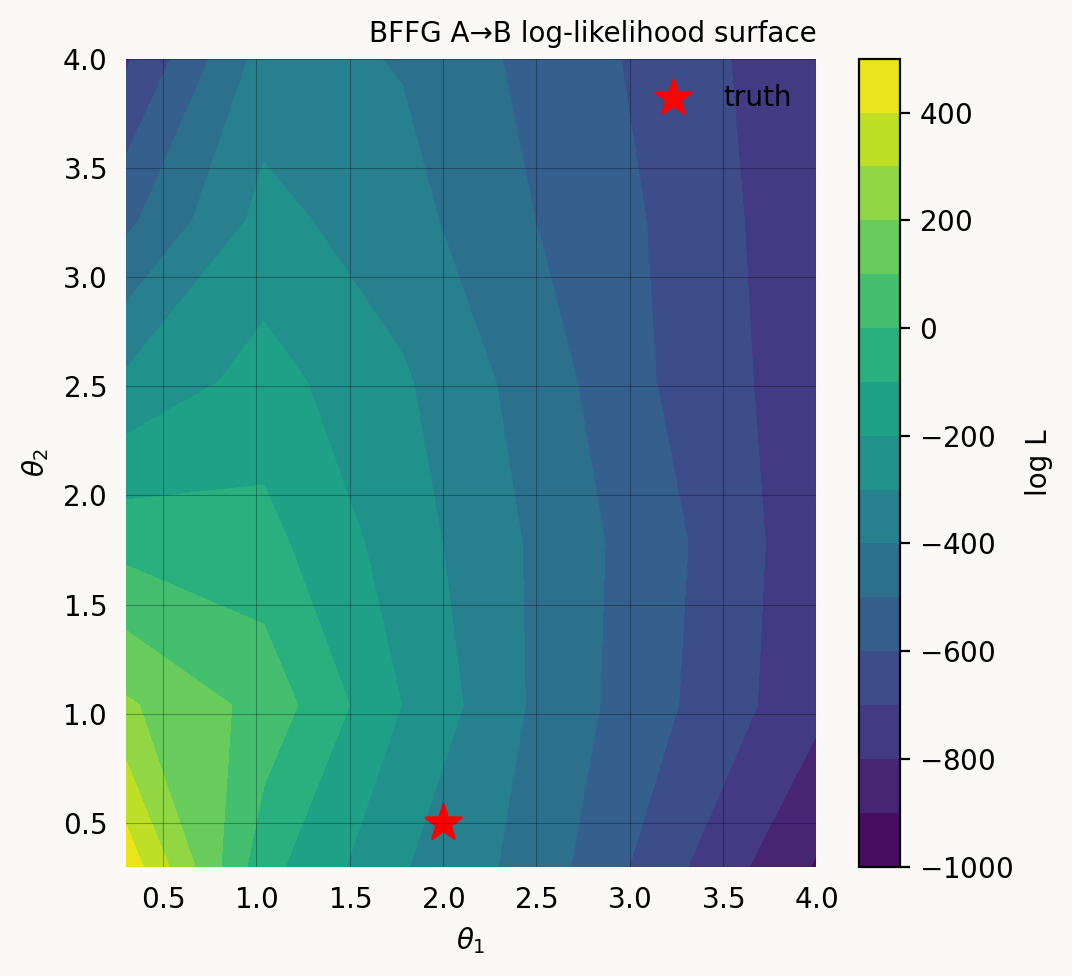

In [13]:
# LL surface using the BFFG (A->B) likelihood
grid_AB = np.linspace(0.3, 4.0, 6)
Z_AB = np.full((len(grid_AB), len(grid_AB)), np.nan)
for i, t1 in enumerate(grid_AB):
    for j, t2 in enumerate(grid_AB):
        Z_AB[i, j] = bffg_log_likelihood_AB(np.array([t1, t2]), observed_data, n_paths=30)

i_max, j_max = np.unravel_index(np.argmax(Z_AB), Z_AB.shape)
print(f"argmax: theta1={grid_AB[i_max]:.2f}, theta2={grid_AB[j_max]:.2f}, ll={Z_AB[i_max,j_max]:.2f}")
print(f"truth:  theta1={TRUE_THETA1:.2f}, theta2={TRUE_THETA2:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
T1_AB, T2_AB = np.meshgrid(grid_AB, grid_AB, indexing='ij')
im = ax.contourf(T1_AB, T2_AB, Z_AB, levels=15, cmap='viridis')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=180, label='truth')
ax.set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$',
       title='BFFG A→B log-likelihood surface')
plt.colorbar(im, ax=ax, label='log L')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
def log_prob_fn_AB(theta):
    return bffg_log_likelihood_AB(theta, observed_data, n_paths=30)

mcmc_AB = MCMC(
    log_prob_fn=log_prob_fn_AB,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=200,
    n_chains=2,
    burn_in=100,
    thin=1,
    proposal_scale=0.25,
    positive_params=True,
    jit=False,
    seed=13,
    verbose=True,
    progress=True,
)
mcmc_AB.run()
mcmc_AB.summary()

results_AB = mcmc_AB.get_results()
samples_AB = results_AB['particles']
chains_AB = results_AB['chains']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for c in range(chains_AB.shape[0]):
    axes[0, 0].plot(chains_AB[c, :, 0], lw=0.6, alpha=0.8)
    axes[0, 1].plot(chains_AB[c, :, 1], lw=0.6, alpha=0.8)
axes[0, 0].axhline(TRUE_THETA1, color='red', ls='--')
axes[0, 1].axhline(TRUE_THETA2, color='red', ls='--')
axes[0, 0].set(title=r'Trace $\theta_1$ (BFFG A→B)', xlabel='iter', ylabel=r'$\theta_1$')
axes[0, 1].set(title=r'Trace $\theta_2$ (BFFG A→B)', xlabel='iter', ylabel=r'$\theta_2$')
axes[1, 0].hist(samples_AB[:, 0], bins=35, color='steelblue', edgecolor='white', density=True)
axes[1, 0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[1, 0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$ (BFFG A→B)')
axes[1, 0].legend()
axes[1, 1].hist(samples_AB[:, 1], bins=35, color='seagreen', edgecolor='white', density=True)
axes[1, 1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1, 1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$ (BFFG A→B)')
axes[1, 1].legend()
plt.tight_layout(); plt.show()
print('R-hat:', results_AB.get('rhat'))
print('ESS:  ', results_AB.get('ess'))


Starting MCMC (2 chains, 200 samples, burn-in=100, adaptive)


### 6c. Closed-form (Jensen) approximation: deterministic expected log w

The Monte Carlo BFFG estimator above is unbiased but high-variance. A useful surrogate is the **Jensen approximation**:

$$
\log \hat w_i^{\text{closed}}(\theta) = E_A[\log w(\pi) | s_i, \theta]  \quad \text{instead of} \quad \log E_A[\exp(\log w(\pi)) | s_i, \theta]
$$

By Jensen's inequality, the Jensen approximation **under-estimates** the true `log E[exp(log w)]` (always: `log E[exp(X)] ≥ E[X]`). The bias is `var_A(log w | s_i)/2` for approximately Gaussian log w, and is the same for every θ near the truth, so it does **not** strongly affect the *shape* of the posterior.

**Practical advantage**: same Monte Carlo paths, but aggregating with `mean(log_w)` instead of `logsumexp(log_w) − log(n_paths)`. The mean has much lower variance than the log-sum-exp, so MCMC mixes much better — at the cost of being biased.

**Use case**: rapid posterior exploration / surface scans. Use the unbiased Monte Carlo version (cell `s6b_loglik`) for the final answer.

**Intuition (your guess was right)**: the θ-dependent part of `log w(π)` factorizes per epoch as

$$
(N_1^B(\pi) - N_1^A(\pi)) \log \theta_1 + (N_2^B(\pi) - N_2^A(\pi)) \log \theta_2 - (P_1^B(\pi) - P_1^A(\pi)) \theta_1 - (P_2^B(\pi) - P_2^A(\pi)) \theta_2
$$

where `N_e^A` = # coalescence events at A-vertices labeled epoch e, `P_e^A` = pair-time at A-epoch-e vertices, and the B-versions use **wall-time** epoch labels. The MLE for θ from this expression *would* be `θ̂_e = N_e^B / P_e^B` per locus — exactly the per-epoch Poisson-process MLE. The BFFG correction is the *deviation* between A's vertex-state view and B's wall-time view, which is non-zero because A's epoch transitions are stochastic around τ rather than deterministic at τ.

In [ ]:
def bffg_log_likelihood_AB_jensen(theta_mcmc, observed_data, n_paths=50, rng=None):
    """Jensen approximation of the BFFG estimator: aggregates log_w via mean()
    instead of logsumexp() − log(n_paths). Same Monte Carlo paths.

    Biased (under-estimates) but much lower variance per call. Useful for
    fast posterior exploration / LL-surface scans. Use `bffg_log_likelihood_AB`
    for the unbiased final answer.
    """
    if rng is None:
        rng = np.random.default_rng(606)
    theta_full = np.array([float(theta_mcmc[0]), float(theta_mcmc[1]),
                           1.0, MUTATION_RATE])
    jg_cont.update_weights(theta_full.tolist())
    jpt_now = jg_cont.joint_prob_table()
    log_p_A_per_tv = {int(tv): float(np.log(max(jpt_now.loc[tv, 'prob'], 1e-300)))
                      for tv in jpt_now.index}

    total_log_lik = 0.0
    for locus in range(len(observed_data)):
        t_v = int(observed_data[locus])
        log_p_A = log_p_A_per_tv.get(t_v, -1e10)
        log_ws = np.empty(n_paths)
        for m in range(n_paths):
            path = jg_cont.sample_path_conditioned([t_v])
            log_ws[m] = compute_path_log_w(path, theta_full, rng)
        # Jensen aggregation: mean instead of logsumexp
        log_w_jensen = float(log_ws.mean())
        total_log_lik += log_p_A + log_w_jensen
    return total_log_lik


# Compare both estimators at the truth and at the proposal
print("Comparing unbiased BFFG vs Jensen approximation on a small dataset:")
true_th = np.array([TRUE_THETA1, TRUE_THETA2])
prop_th = np.array([THETA_0, THETA_0])
np.random.seed(7)
for label, th in [("proposal", prop_th), ("truth", true_th)]:
    ll_unb = bffg_log_likelihood_AB(th, observed_data, n_paths=30)
    ll_jen = bffg_log_likelihood_AB_jensen(th, observed_data, n_paths=30)
    print(f"  at {label} {th}: unbiased = {ll_unb:.3f}, Jensen = {ll_jen:.3f}, gap = {ll_unb - ll_jen:.3f}")

In [ ]:
# LL surface using the Jensen-approximation BFFG
grid_jen = np.linspace(0.3, 4.0, 6)
Z_jen = np.full((len(grid_jen), len(grid_jen)), np.nan)
for i, t1 in enumerate(grid_jen):
    for j, t2 in enumerate(grid_jen):
        Z_jen[i, j] = bffg_log_likelihood_AB_jensen(np.array([t1, t2]), observed_data, n_paths=30)

i_max, j_max = np.unravel_index(np.argmax(Z_jen), Z_jen.shape)
print(f"Jensen LL surface argmax: theta1={grid_jen[i_max]:.2f}, theta2={grid_jen[j_max]:.2f}, ll={Z_jen[i_max,j_max]:.2f}")
print(f"truth:                     theta1={TRUE_THETA1:.2f}, theta2={TRUE_THETA2:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
T1_jen, T2_jen = np.meshgrid(grid_jen, grid_jen, indexing='ij')
im = ax.contourf(T1_jen, T2_jen, Z_jen, levels=15, cmap='viridis')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=180, label='truth')
ax.set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$',
       title='BFFG A→B log-likelihood (Jensen approx) surface')
plt.colorbar(im, ax=ax, label='log L')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# MCMC with the Jensen approximation (lower-variance log_prob → better mixing)
def log_prob_fn_AB_jensen(theta):
    return bffg_log_likelihood_AB_jensen(theta, observed_data, n_paths=30)

mcmc_AB_jen = MCMC(
    log_prob_fn=log_prob_fn_AB_jensen,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=200,
    n_chains=2,
    burn_in=100,
    thin=1,
    proposal_scale=0.25,
    positive_params=True,
    jit=False,
    seed=17,
    verbose=True,
    progress=True,
)
mcmc_AB_jen.run()
mcmc_AB_jen.summary()

results_jen = mcmc_AB_jen.get_results()
samples_jen = results_jen['particles']
chains_jen = results_jen['chains']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for c in range(chains_jen.shape[0]):
    axes[0, 0].plot(chains_jen[c, :, 0], lw=0.6, alpha=0.8)
    axes[0, 1].plot(chains_jen[c, :, 1], lw=0.6, alpha=0.8)
axes[0, 0].axhline(TRUE_THETA1, color='red', ls='--')
axes[0, 1].axhline(TRUE_THETA2, color='red', ls='--')
axes[0, 0].set(title=r'Trace $\theta_1$ (BFFG A→B Jensen)', xlabel='iter', ylabel=r'$\theta_1$')
axes[0, 1].set(title=r'Trace $\theta_2$ (BFFG A→B Jensen)', xlabel='iter', ylabel=r'$\theta_2$')
axes[1, 0].hist(samples_jen[:, 0], bins=35, color='steelblue', edgecolor='white', density=True)
axes[1, 0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[1, 0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$ (BFFG A→B Jensen)')
axes[1, 0].legend()
axes[1, 1].hist(samples_jen[:, 1], bins=35, color='seagreen', edgecolor='white', density=True)
axes[1, 1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1, 1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$ (BFFG A→B Jensen)')
axes[1, 1].legend()
plt.tight_layout(); plt.show()
print('R-hat:', results_jen.get('rhat'))
print('ESS:  ', results_jen.get('ess'))

## 7. Diagnostic plots before MCMC

Sanity-check the importance sampler: weight distributions, ESS per locus, log-likelihood surface near the truth.

> **Note on variance.** When the target rates `[θ₁, θ₂]` are far from the proposal rate `θ₀`, the importance weights have very high variance — the per-locus log-weight histogram below will show a long right tail. With small `n_paths` and many loci, this manifests as poor MCMC mixing (low acceptance, high R-hat). For realistic inference you would either pick a proposal closer to the bulk of the posterior, increase `n_paths` substantially (200+), or use a per-iteration adaptive proposal. Section 10 compares against the package's `bffg_log_prob` which uses a different (deterministic, seed-fixed) variance trade-off.

BFFG log-likelihood at truth: -528.17


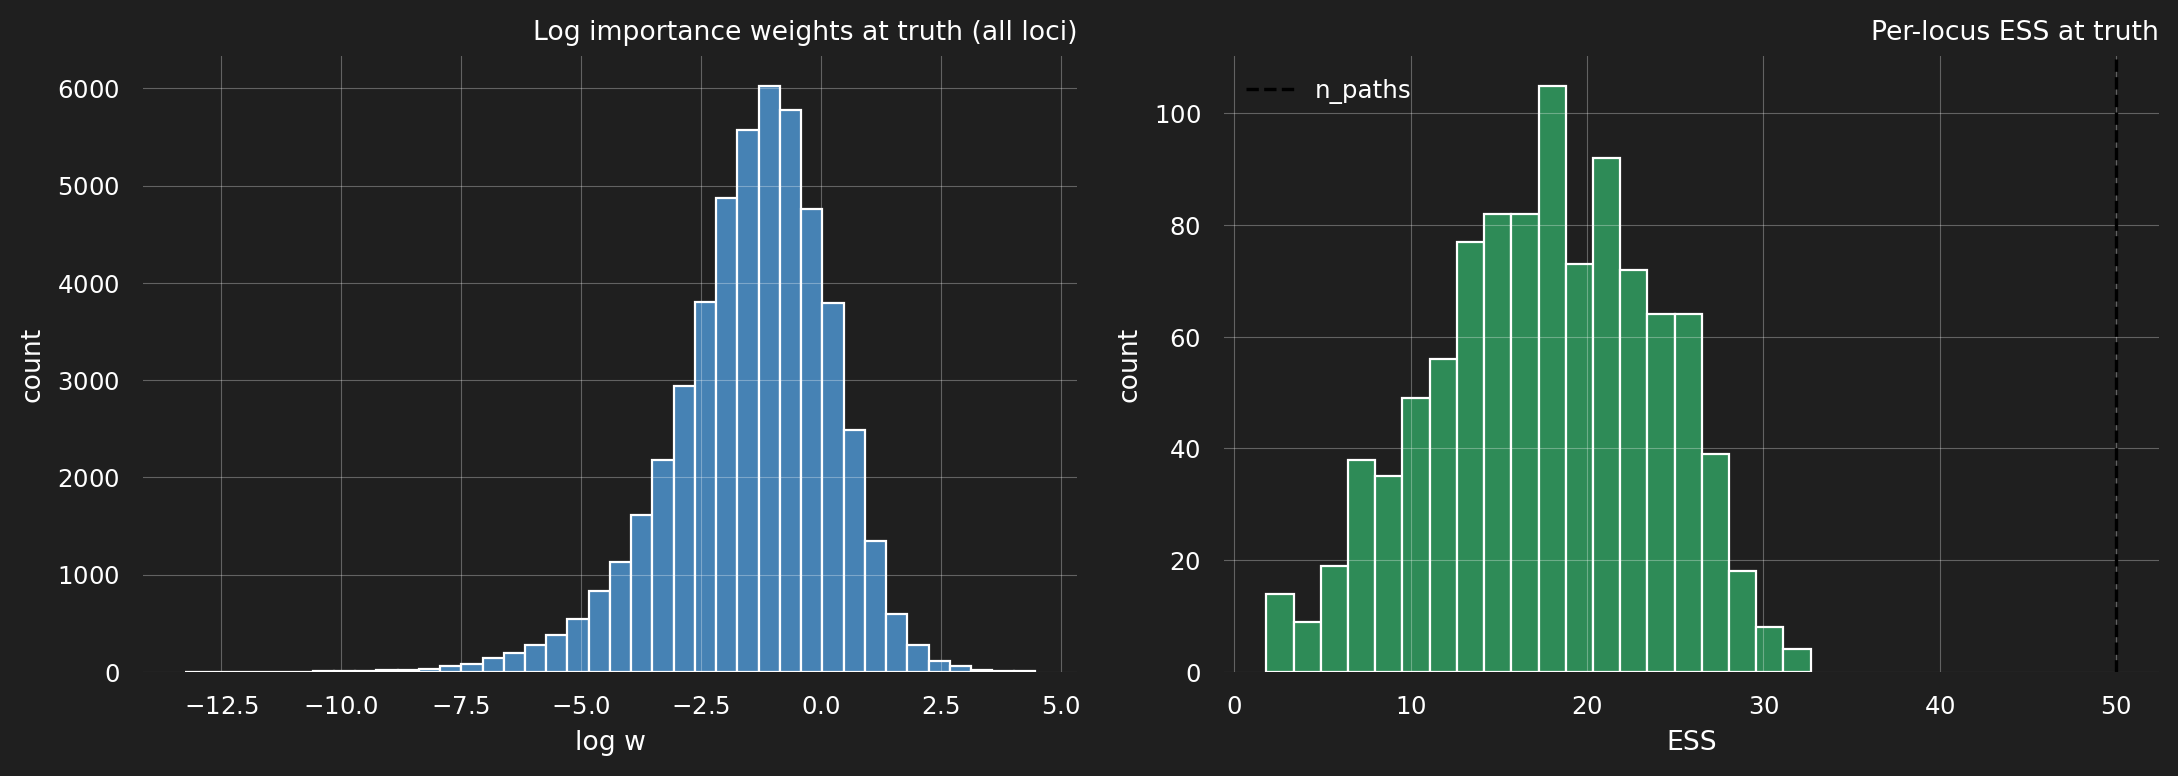

In [ ]:
# Diagnostic 1: log-weight distributions and ESS at the true parameters
true_theta_mcmc = np.array([TRUE_THETA1, TRUE_THETA2])
ll_true, diag = bffg_log_likelihood(true_theta_mcmc, observed_data, n_paths=50,
                                     return_diagnostics=True)
print(f"BFFG log-likelihood at truth: {ll_true:.2f}")
all_log_w = np.concatenate(diag['log_weights_per_locus'])
ess = np.array(diag['ess_per_locus'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(all_log_w, bins=40, color='steelblue', edgecolor='white')
axes[0].set(xlabel='log w', ylabel='count', title='Log importance weights at truth (all loci)')
axes[1].hist(ess, bins=20, color='seagreen', edgecolor='white')
axes[1].axvline(50, color='k', ls='--', label='n_paths')
axes[1].set(xlabel='ESS', ylabel='count', title='Per-locus ESS at truth')
axes[1].legend()
plt.tight_layout(); plt.show()

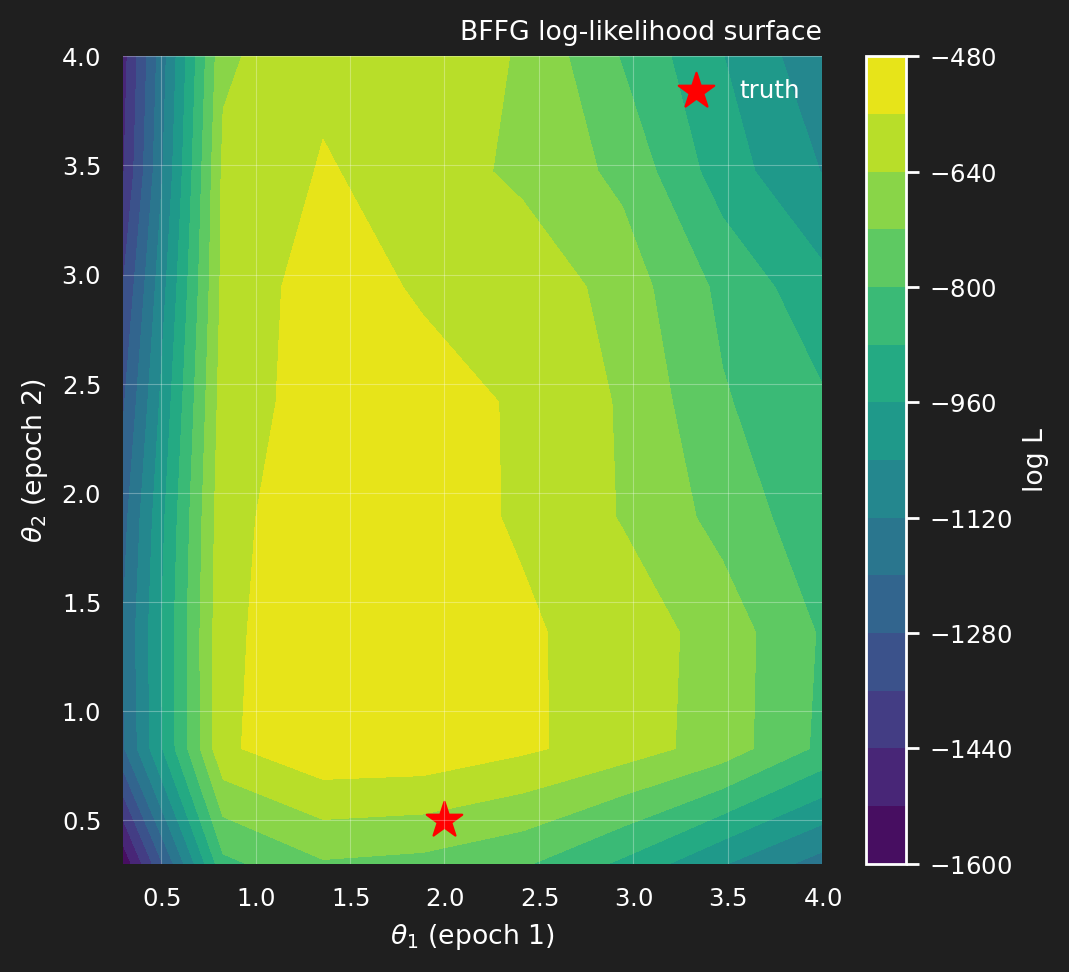

argmax: theta1=1.36, theta2=0.83
truth:  theta1=2.00, theta2=0.50


In [ ]:
# Diagnostic 2: log-likelihood surface over (theta1, theta2)
grid = np.linspace(0.3, 4.0, 8)
Z = np.full((len(grid), len(grid)), np.nan)
for i, t1 in enumerate(grid):
    for j, t2 in enumerate(grid):
        Z[i, j] = bffg_log_likelihood(np.array([t1, t2]), observed_data, n_paths=20)

fig, ax = plt.subplots(figsize=(5.5, 5))
T1, T2 = np.meshgrid(grid, grid, indexing='ij')
im = ax.contourf(T1, T2, Z, levels=15, cmap='viridis')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=180, label='truth')
ax.set(xlabel=r'$\theta_1$ (epoch 1)', ylabel=r'$\theta_2$ (epoch 2)',
       title='BFFG log-likelihood surface')
plt.colorbar(im, ax=ax, label='log L')
ax.legend(); plt.tight_layout(); plt.show()

# argmax
i_max, j_max = np.unravel_index(np.argmax(Z), Z.shape)
print(f"argmax: theta1={grid[i_max]:.2f}, theta2={grid[j_max]:.2f}")
print(f"truth:  theta1={TRUE_THETA1:.2f}, theta2={TRUE_THETA2:.2f}")

## 8. MCMC inference

Plug the BFFG log-likelihood into `MCMC` via the `log_prob_fn` mode (the cleanest route — `bffg_log_prob` from the package implements the same idea but uses an exit-rate ratio instead of the event-density form, and is geared toward the FFI/JIT path).

In [ ]:
def log_prob_fn(theta):
    return bffg_log_likelihood(theta, observed_data, n_paths=20)

mcmc = MCMC(
    log_prob_fn=log_prob_fn,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=200,
    n_chains=2,
    burn_in=100,
    thin=1,
    proposal_scale=0.25,
    positive_params=True,
    jit=False,           # log_prob_fn calls back into Python/numpy
    seed=7,
    verbose=True,
    progress=True,
)
mcmc.run()
mcmc.summary()

  Chain 1: acceptance rate = 0.010
  Chain 2: acceptance rate = 0.050

MCMC complete!
Posterior mean: [1.54628992 1.20548785]
Posterior std:  [0.1603544 0.3154094]
R-hat:          [1.24999562 0.99867834]

MCMC Summary (2 chains, 200 samples/chain)
----------------------------------------------------------------------
Param          Mean        Std   HPD 2.5%  HPD 97.5%    R-hat      ESS
----------------------------------------------------------------------
theta[0]      1.5463     0.1604     1.3078     2.1086   1.2500      8.5
theta[1]      1.2055     0.3154     0.8500     1.5651   0.9987     60.0
----------------------------------------------------------------------
Acceptance rates: 0.010, 0.050


## 9. Posterior diagnostics

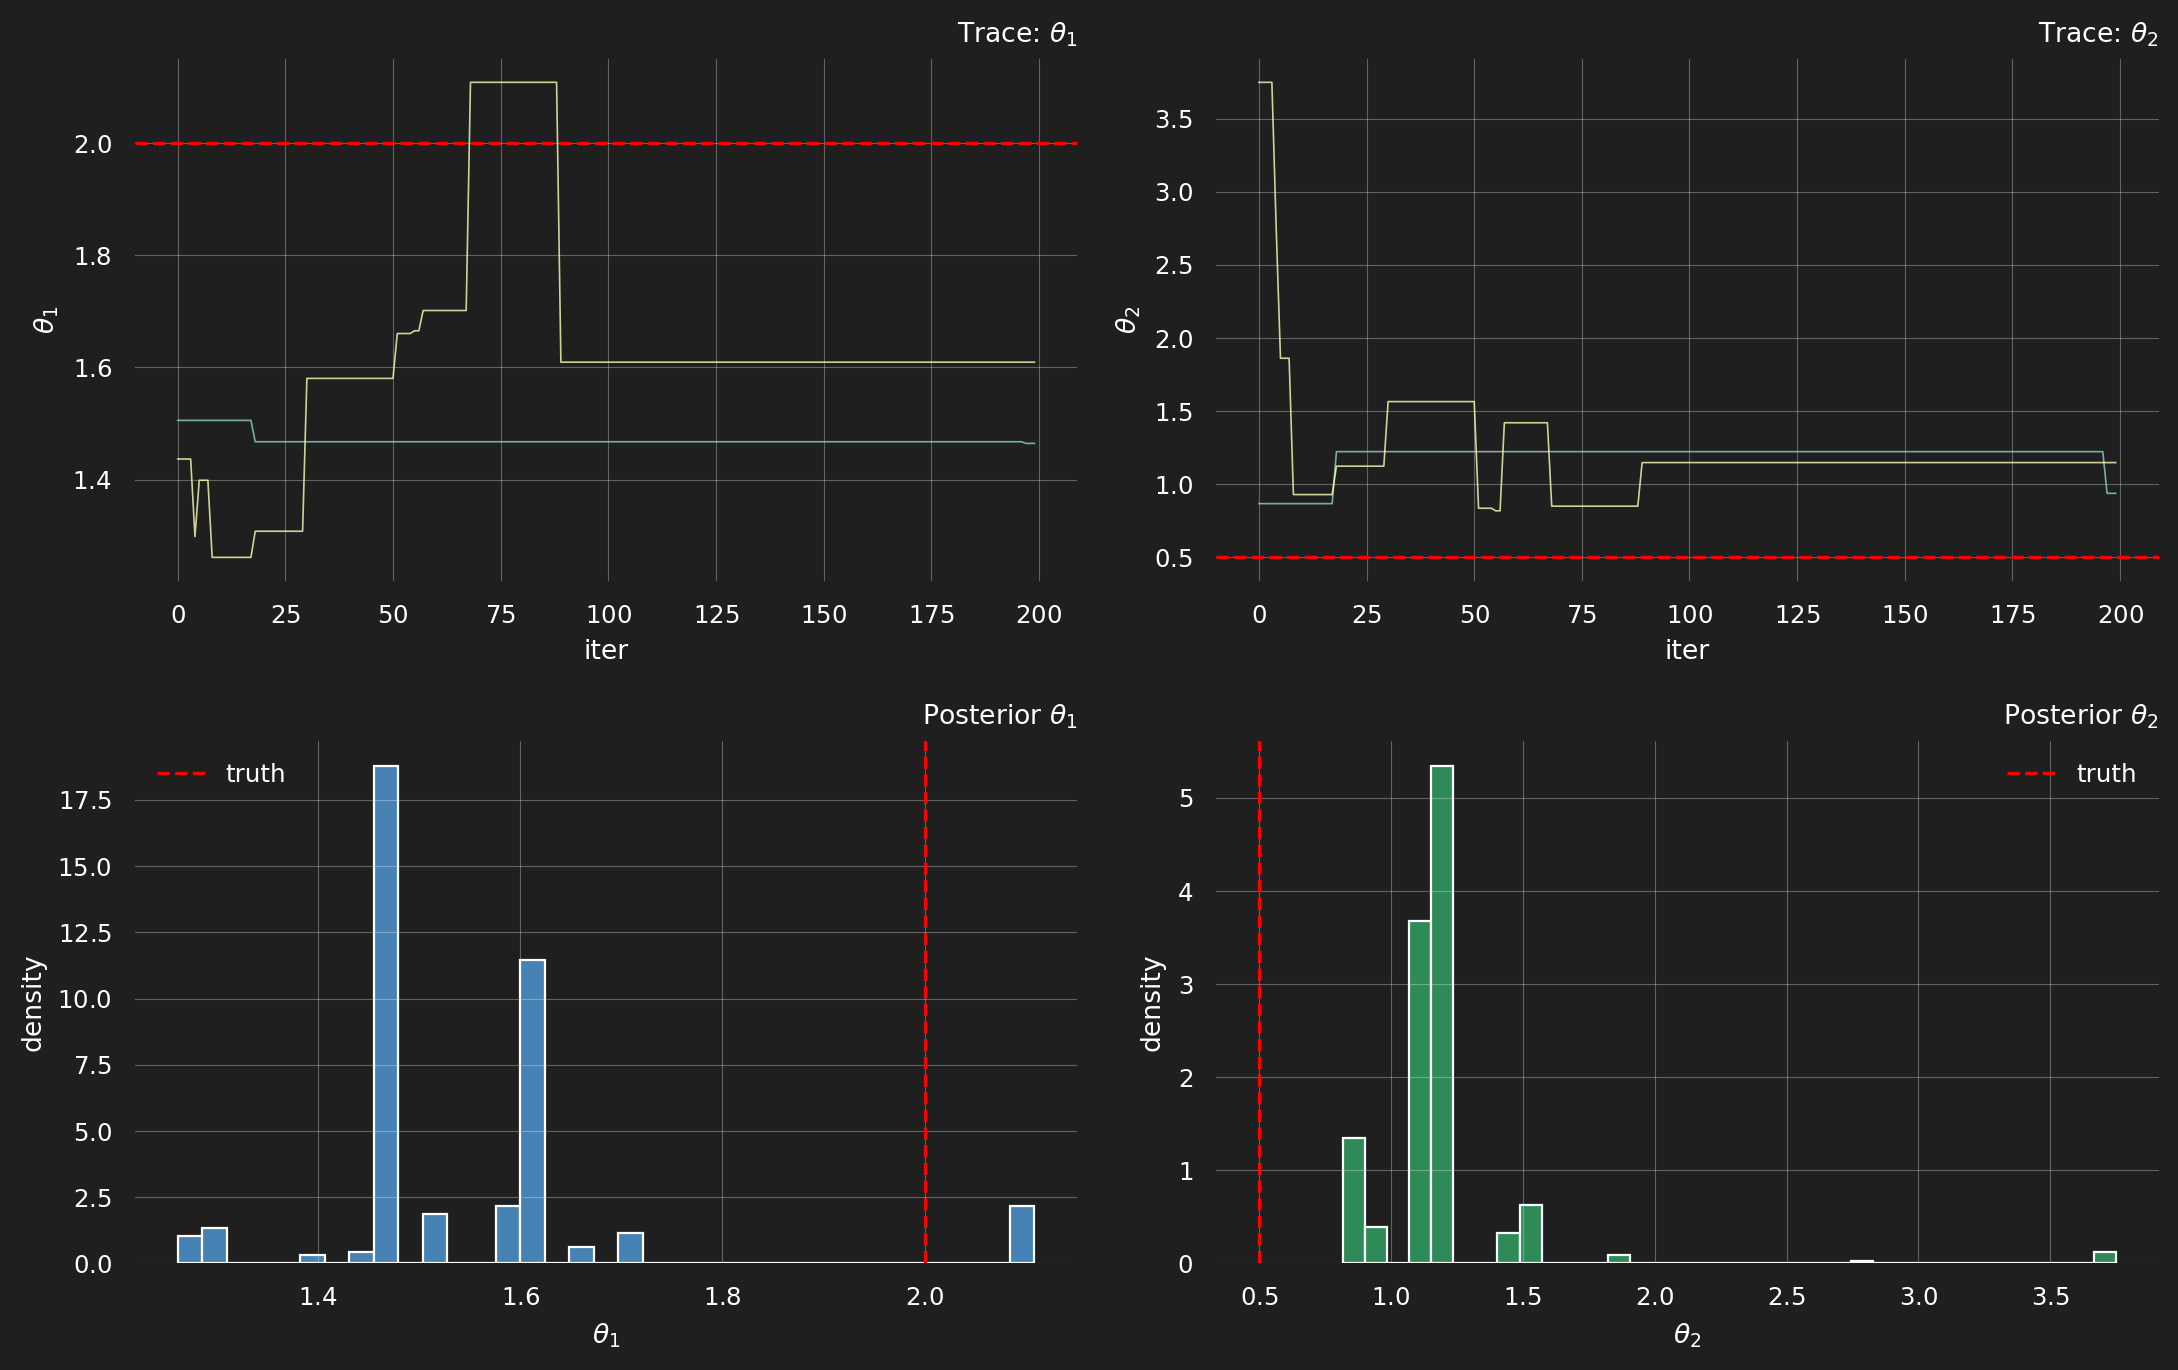

In [ ]:
results = mcmc.get_results()
chains = results['chains']  # (n_chains, n_samples, 2)
samples = results['particles']  # (n_total, 2)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# trace plots
for c in range(chains.shape[0]):
    axes[0, 0].plot(chains[c, :, 0], lw=0.6, alpha=0.8)
    axes[0, 1].plot(chains[c, :, 1], lw=0.6, alpha=0.8)
axes[0, 0].axhline(TRUE_THETA1, color='red', ls='--')
axes[0, 1].axhline(TRUE_THETA2, color='red', ls='--')
axes[0, 0].set(title=r'Trace: $\theta_1$', xlabel='iter', ylabel=r'$\theta_1$')
axes[0, 1].set(title=r'Trace: $\theta_2$', xlabel='iter', ylabel=r'$\theta_2$')

# marginal posteriors
axes[1, 0].hist(samples[:, 0], bins=35, color='steelblue', edgecolor='white', density=True)
axes[1, 0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[1, 0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$')
axes[1, 0].legend()

axes[1, 1].hist(samples[:, 1], bins=35, color='seagreen', edgecolor='white', density=True)
axes[1, 1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1, 1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

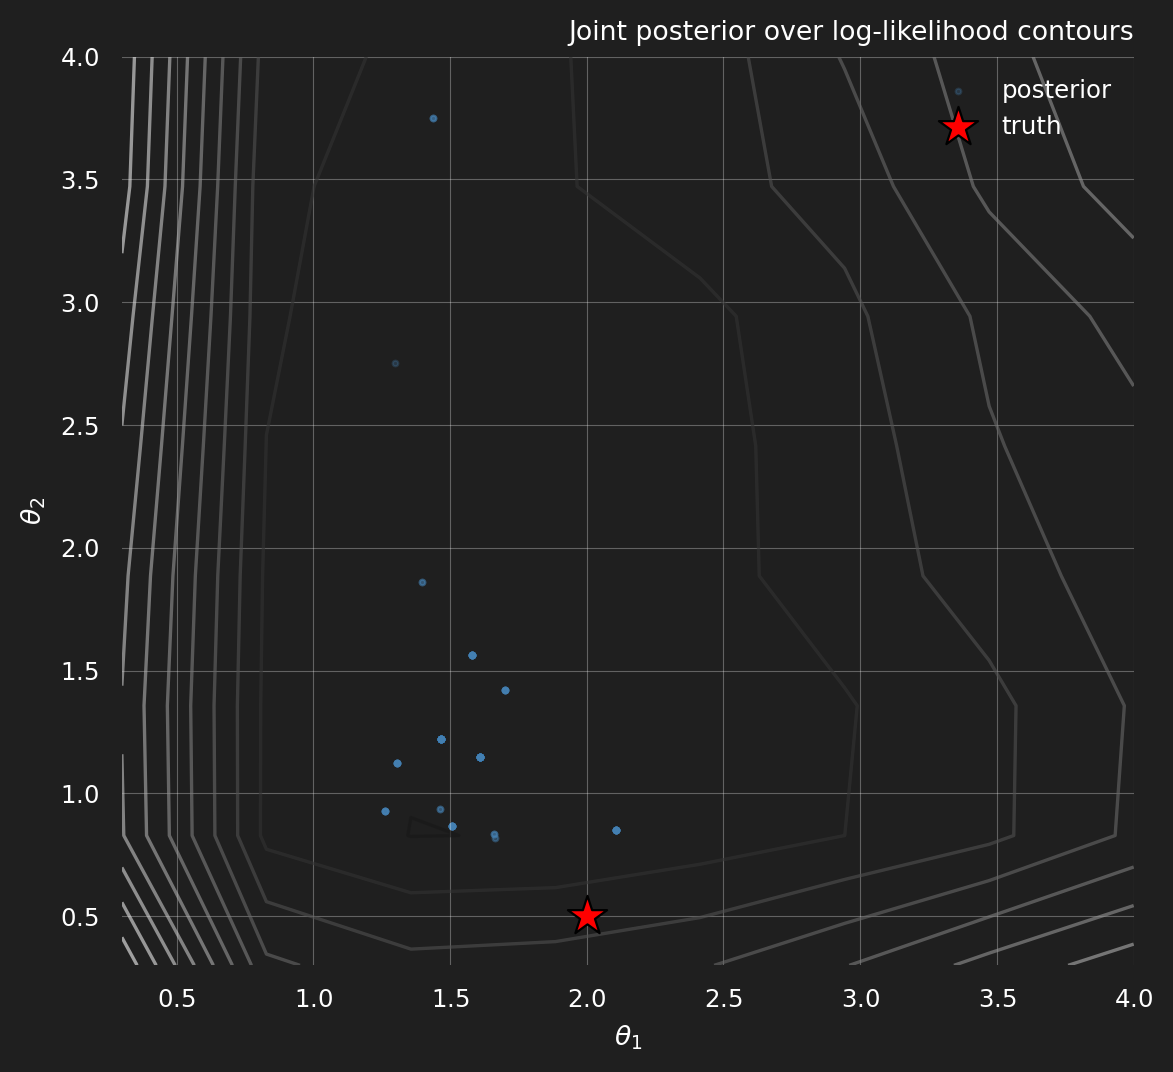

In [ ]:
# joint posterior + log-likelihood contours
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contour(T1, T2, Z, levels=10, cmap='Greys', alpha=0.6)
ax.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.25, color='steelblue', label='posterior')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=220,
           edgecolor='black', label='truth', zorder=5)
ax.set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$',
       title='Joint posterior over log-likelihood contours')
ax.legend(); plt.tight_layout(); plt.show()

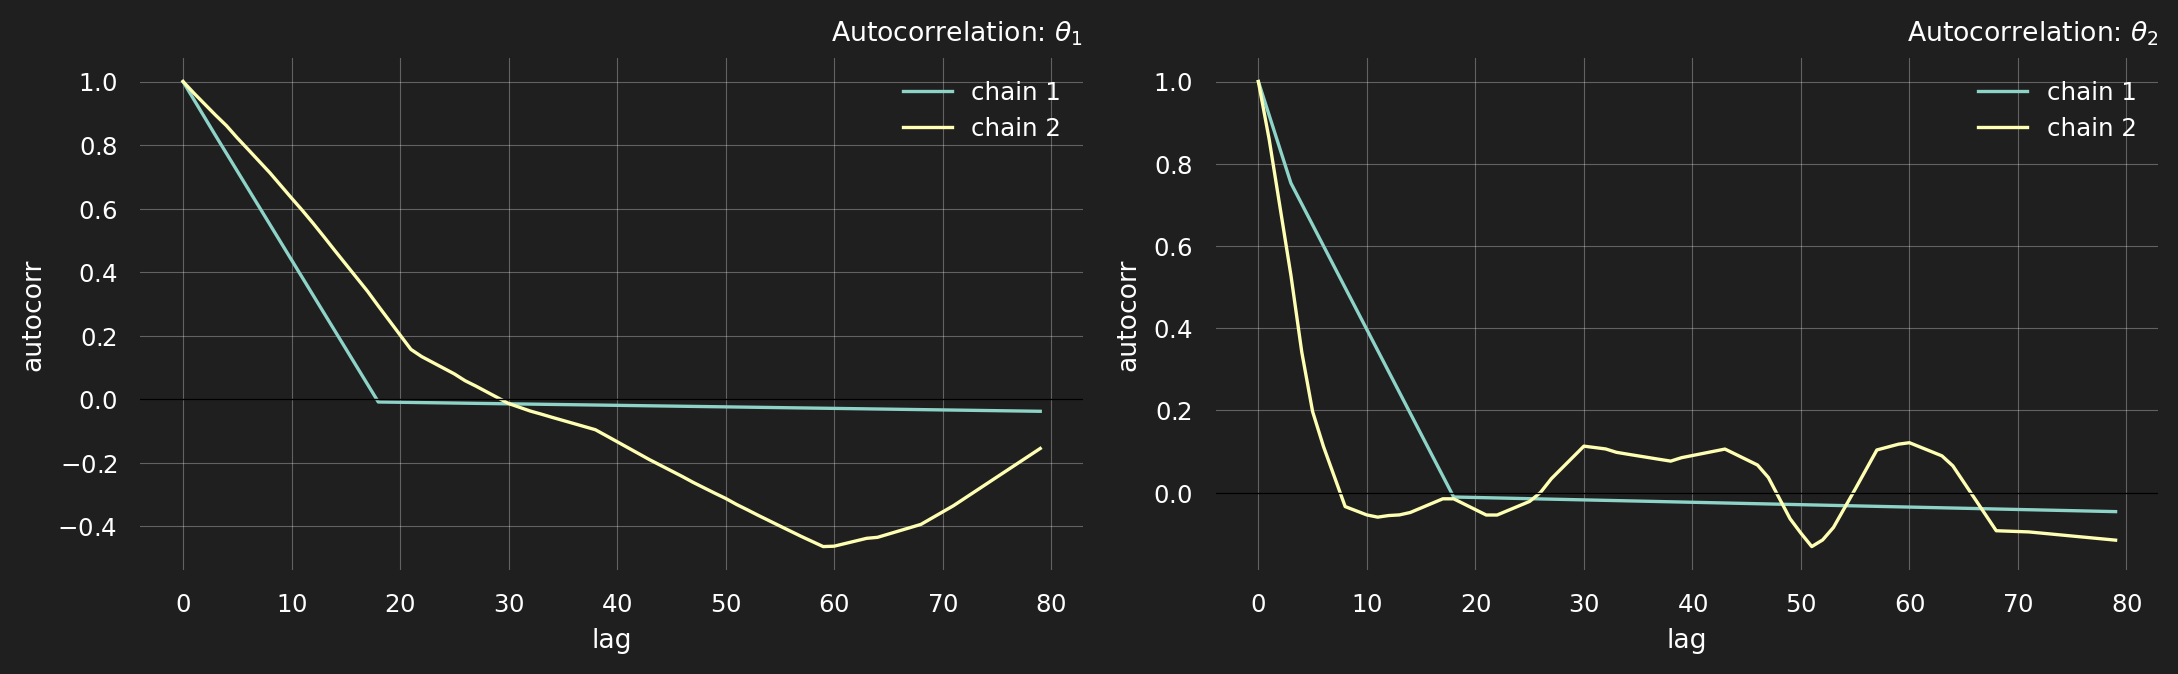

R-hat: [1.24999562 0.99867834]
ESS:   [ 8.51630295 60.03834168]


In [ ]:
# Per-chain autocorrelation
from numpy.fft import fft, ifft

def autocorr(x, max_lag=80):
    x = x - x.mean()
    n = len(x)
    f = fft(x, n=2*n)
    acf = ifft(f * np.conj(f)).real[:max_lag] / (n * x.var())
    return acf

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for c in range(chains.shape[0]):
    axes[0].plot(autocorr(chains[c, :, 0]), label=f'chain {c+1}')
    axes[1].plot(autocorr(chains[c, :, 1]), label=f'chain {c+1}')
for ax, name in zip(axes, [r'$\theta_1$', r'$\theta_2$']):
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='lag', ylabel='autocorr', title=f'Autocorrelation: {name}')
    ax.legend()
plt.tight_layout(); plt.show()

print('R-hat:', results.get('rhat'))
print('ESS:  ', results.get('ess'))

## 10. Compare with the package's `bffg_log_prob`

The library ships a ready-made BFFG inference helper that returns a JIT-compatible model term plus a stochastic correction. It uses a **different importance-weight formulation** than ours:

- **Manual (sections 4–9):** event-density form, exploiting the special structure of homogeneous coalescent proposal vs piecewise-constant target. Requires us to know that the model is a coalescent.
- **Package (`bffg_log_prob`):** generic exit-rate-ratio form,
$$
\log w = \sum_{\text{transient }v} \bigl[\log r^{\text{tgt}}_v - \log r^{\text{prop}}_v\bigr] - (r^{\text{tgt}}_v - r^{\text{prop}}_v)\,s_v + \log\frac{p^{\text{tgt}}_{v\to v'}}{p^{\text{prop}}_{v\to v'}}
$$
which works for any phase-type graph but evaluates `theta_target_fn` at every transient vertex along the path.

The two estimators target the same posterior but have different variance profiles. We run MCMC with the package version and overlay both posteriors.

In [ ]:
from phasic import bffg_log_prob
import jax
import jax.numpy as jnp

# bffg_log_prob expects:
#   theta_proposal: GRAPH-level parameter vector (length = jg.param_length() = 4 here)
#   theta_target_fn(theta_mcmc, t): returns a GRAPH-level vector at time t. With the
#       epoch model the time-inhomogeneity is encoded topologically, so theta_target_fn
#       returns the SAME constant vector for all t — the "t" argument is ignored.
#   theta_proposal_fn(theta_mcmc): JAX-traceable; returns the GRAPH-level vector used
#       by the model term (which is evaluated under the homogeneous proposal).

def theta_target_fn_pkg(theta_mcmc, t):
    """Graph-level theta vector — constant in time since epochs are encoded as states."""
    return jnp.array([theta_mcmc[0], theta_mcmc[1], 1.0, MUTATION_RATE])


def theta_proposal_fn_pkg(theta_mcmc):
    """Model term uses the homogeneous proposal regardless of theta_mcmc."""
    return jnp.array([THETA_0, THETA_0, 1.0, MUTATION_RATE])


# Re-prime jg_cont to the proposal (joint_prob_table caching); also need a discrete
# joint graph view for the FFI model term — bffg_log_prob accepts the same graph for both.
jg_cont.update_weights(theta_proposal.tolist())

model_pkg, correction_pkg = bffg_log_prob(
    jg_disc=jg_cont,
    jg_continuous=jg_cont,
    theta_proposal=theta_proposal,
    theta_target_fn=theta_target_fn_pkg,
    observed_data=observed_data,
    n_paths=50,
    theta_proposal_fn=theta_proposal_fn_pkg,
    return_model=True,
)

# Sanity check: evaluate at the truth
true_theta_mcmc_jnp = jnp.array([TRUE_THETA1, TRUE_THETA2])
probs, _ = model_pkg(true_theta_mcmc_jnp, jnp.array(observed_data, dtype=jnp.int32))
log_p_model_truth = float(jnp.sum(jnp.log(probs + 1e-30)))
log_corr_truth = float(correction_pkg(true_theta_mcmc_jnp))
print(f"Package BFFG at truth:  log P_model = {log_p_model_truth:.2f}, "
      f"log E[w] = {log_corr_truth:.2f}, total = {log_p_model_truth + log_corr_truth:.2f}")
print(f"Manual  BFFG at truth:  total = {ll_true:.2f}")

Package BFFG at truth:  log P_model = -535.91, log E[w] = 18.88, total = -517.03
Manual  BFFG at truth:  total = -528.17


In [ ]:
# Run MCMC using the package's (model, likelihood_correction) split.
# The model term uses the FFI trace cache (JIT-compatible), the correction
# uses sampled paths (non-JIT). MCMC.likelihood_correction adds the
# correction outside the JIT'd model evaluation.

mcmc_pkg = MCMC(
    model=model_pkg,
    observed_data=jnp.array(observed_data, dtype=jnp.int32),
    likelihood_correction=correction_pkg,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=2000,
    n_chains=2,
    burn_in=200,
    thin=5,
    proposal_scale=0.25,
    positive_params=True,
    jit=True,             # the model term jits; correction stays in Python
    seed=7,
    verbose=True,
    progress=True,
)
mcmc_pkg.run()
mcmc_pkg.summary()

  Chain 1: acceptance rate = 0.241
  Chain 2: acceptance rate = 0.214

MCMC complete!
Posterior mean: [1.86727661 1.23225405]
Posterior std:  [0.10226886 0.22816094]
R-hat:          [0.99997121 0.99996233]

MCMC Summary (2 chains, 2000 samples/chain)
----------------------------------------------------------------------
Param          Mean        Std   HPD 2.5%  HPD 97.5%    R-hat      ESS
----------------------------------------------------------------------
theta[0]      1.8673     0.1023     1.6679     2.0590   1.0000   2113.0
theta[1]      1.2323     0.2282     0.8120     1.6612   1.0000   1874.4
----------------------------------------------------------------------
Acceptance rates: 0.241, 0.214


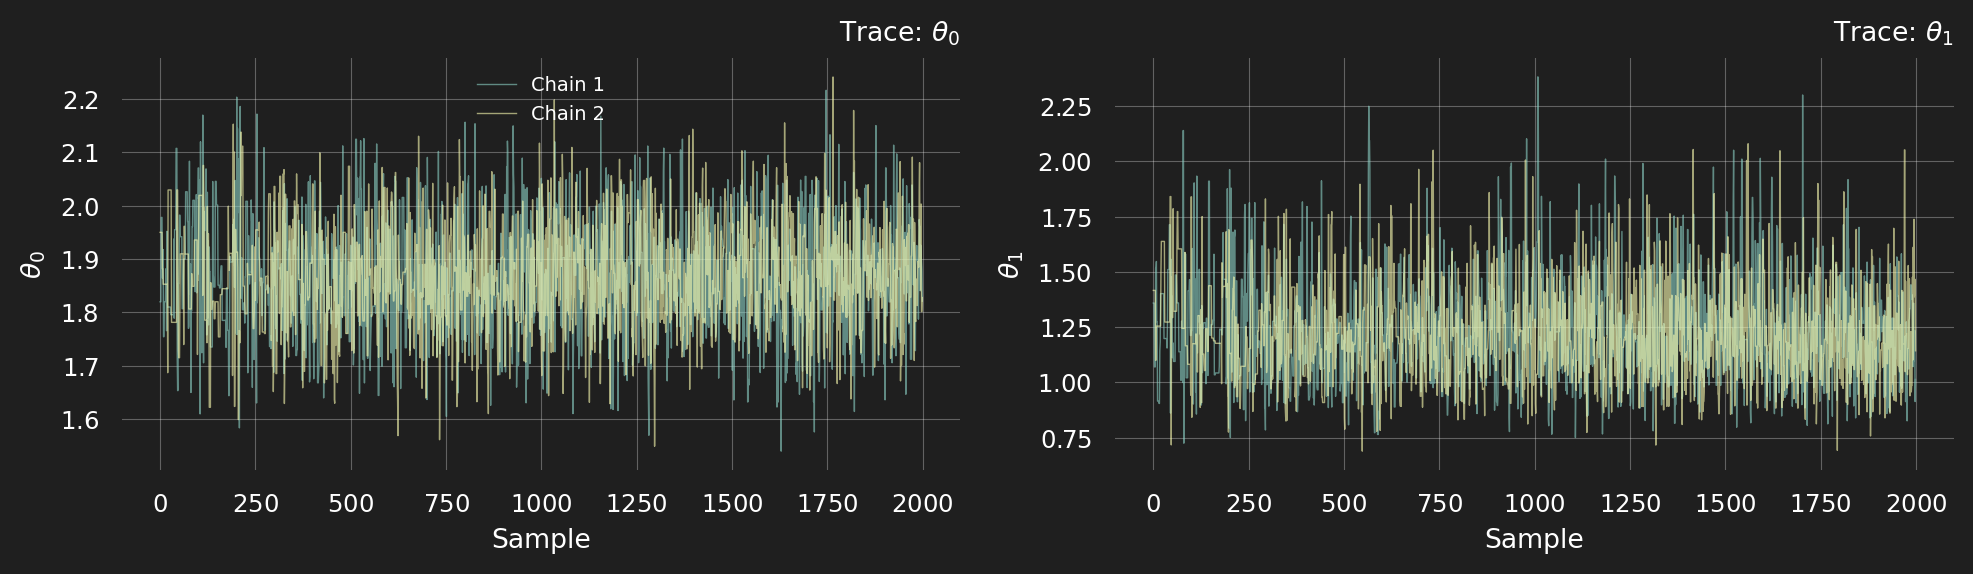

In [ ]:
mcmc_pkg.plot_chains()

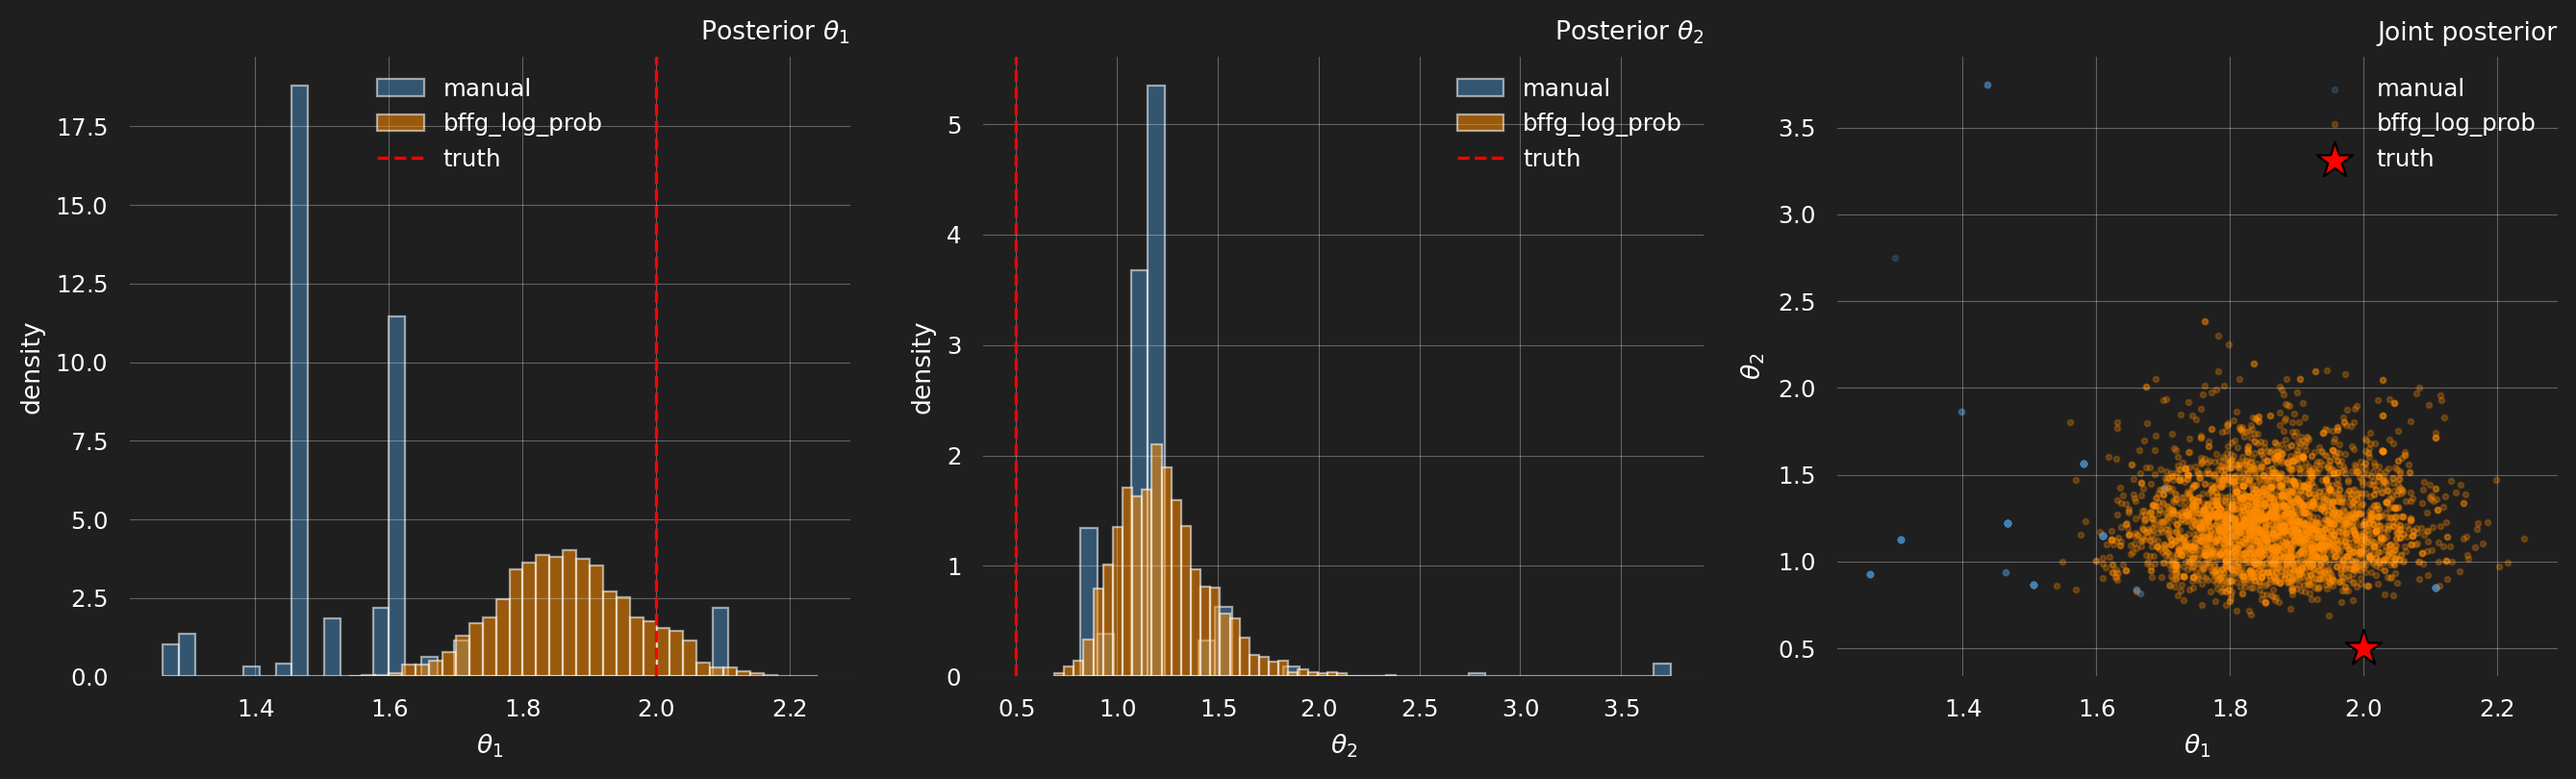

Posterior means:
  manual:        theta1 = 1.546, theta2 = 1.205
  bffg_log_prob: theta1 = 1.867, theta2 = 1.232
  truth:         theta1 = 2.0, theta2 = 0.5


In [ ]:
# Overlay the two posteriors
results_pkg = mcmc_pkg.get_results()
samples_pkg = results_pkg['particles']
chains_pkg = results_pkg['chains']

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# Marginal: theta1
axes[0].hist(samples[:, 0], bins=35, density=True, alpha=0.55,
             color='steelblue', edgecolor='white', label='manual')
axes[0].hist(samples_pkg[:, 0], bins=35, density=True, alpha=0.55,
             color='darkorange', edgecolor='white', label='bffg_log_prob')
axes[0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$')
axes[0].legend()

# Marginal: theta2
axes[1].hist(samples[:, 1], bins=35, density=True, alpha=0.55,
             color='steelblue', edgecolor='white', label='manual')
axes[1].hist(samples_pkg[:, 1], bins=35, density=True, alpha=0.55,
             color='darkorange', edgecolor='white', label='bffg_log_prob')
axes[1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$')
axes[1].legend()

# Joint scatter
axes[2].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.25,
                color='steelblue', label='manual')
axes[2].scatter(samples_pkg[:, 0], samples_pkg[:, 1], s=4, alpha=0.25,
                color='darkorange', label='bffg_log_prob')
axes[2].scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=200,
                edgecolor='black', zorder=5, label='truth')
axes[2].set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$', title='Joint posterior')
axes[2].legend()

plt.tight_layout(); plt.show()

print("Posterior means:")
print(f"  manual:        theta1 = {results['theta_mean'][0]:.3f}, "
      f"theta2 = {results['theta_mean'][1]:.3f}")
print(f"  bffg_log_prob: theta1 = {results_pkg['theta_mean'][0]:.3f}, "
      f"theta2 = {results_pkg['theta_mean'][1]:.3f}")
print(f"  truth:         theta1 = {TRUE_THETA1}, theta2 = {TRUE_THETA2}")

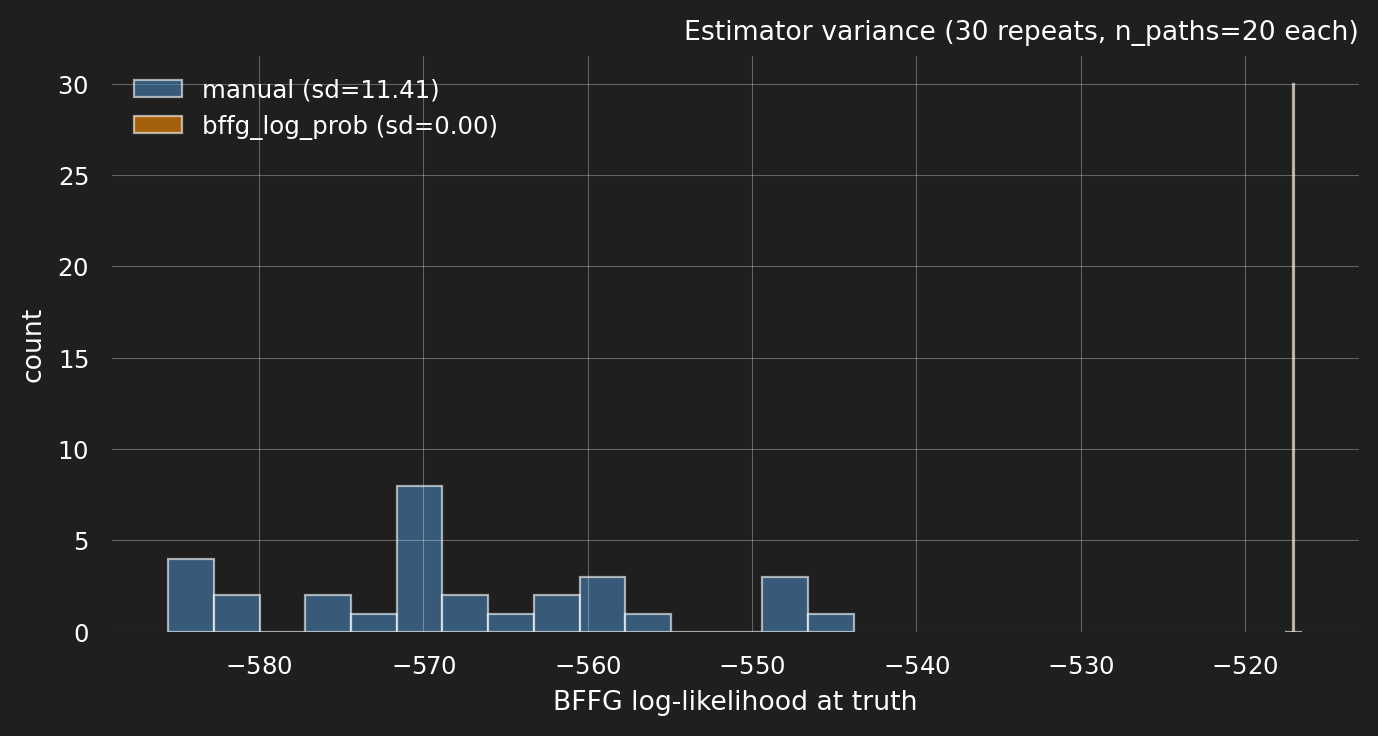

Manual:        mean = -567.54, sd = 11.41
bffg_log_prob: mean = -517.03, sd = 0.00


In [ ]:
# Per-evaluation comparison: stack repeated log-likelihood evaluations at the truth
# to compare estimator variance between the two BFFG implementations.
n_repeats = 30

ll_manual = np.array([
    bffg_log_likelihood(true_theta_mcmc, observed_data, n_paths=20)
    for _ in range(n_repeats)
])

# Package version: model term is deterministic given theta, correction is stochastic
probs_truth, _ = model_pkg(true_theta_mcmc_jnp, jnp.array(observed_data, dtype=jnp.int32))
log_p_model = float(jnp.sum(jnp.log(probs_truth + 1e-30)))
ll_pkg = np.array([
    log_p_model + float(correction_pkg(true_theta_mcmc_jnp))
    for _ in range(n_repeats)
])

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(ll_manual, bins=15, alpha=0.6, color='steelblue', edgecolor='white',
        label=f'manual (sd={ll_manual.std():.2f})')
ax.hist(ll_pkg, bins=15, alpha=0.6, color='darkorange', edgecolor='white',
        label=f'bffg_log_prob (sd={ll_pkg.std():.2f})')
ax.set(xlabel='BFFG log-likelihood at truth', ylabel='count',
       title=f'Estimator variance ({n_repeats} repeats, n_paths=20 each)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Manual:        mean = {ll_manual.mean():.2f}, sd = {ll_manual.std():.2f}")
print(f"bffg_log_prob: mean = {ll_pkg.mean():.2f}, sd = {ll_pkg.std():.2f}")

## 11. Posterior predictive check

Draw a posterior parameter sample, simulate fresh observations under it, compare the implied SFS counts to those observed.

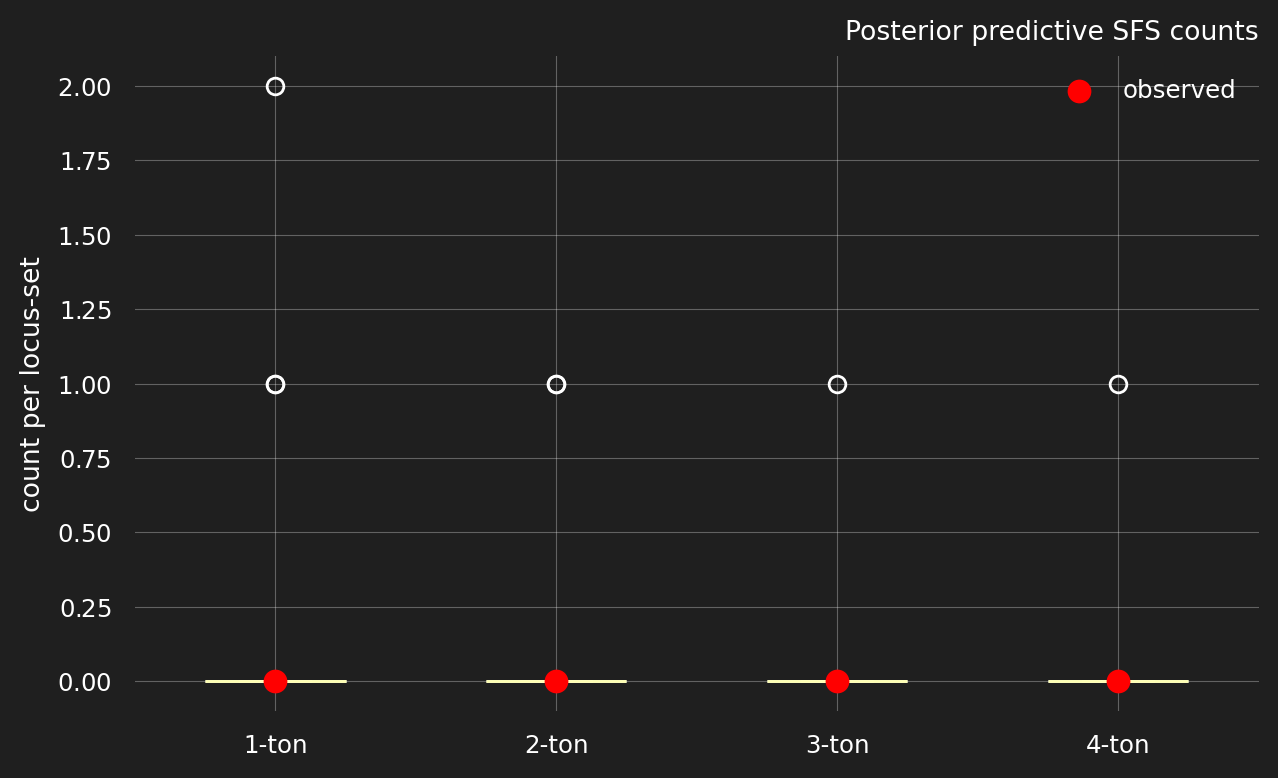

In [ ]:
n_pred = 30
pred_counts = np.zeros((n_pred, N_SAMPLES - 1), dtype=int)
post_idx = rng.choice(samples.shape[0], size=n_pred, replace=False)
pred_rng = np.random.default_rng(401)
for k, idx in enumerate(post_idx):
    th = np.asarray(samples[idx])
    th_full = np.array([float(th[0]), float(th[1]), 1.0, MUTATION_RATE])
    for _ in range(N_LOCI):
        try:
            term = simulate_observation(th_full, edge_cache_cont, v_start_idx,
                                         valid_t_vertices, trash_vertices, pred_rng)
            j = term_to_type.get(int(term))
            if j is not None and 1 <= j <= N_SAMPLES - 1:
                pred_counts[k, j - 1] += 1
        except RuntimeError:
            continue

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(N_SAMPLES - 1)
ax.boxplot([pred_counts[:, j] for j in x], positions=x, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter(x, mut_type_counts, color='red', zorder=5, label='observed', s=60)
ax.set_xticks(x)
ax.set_xticklabels([f'{j+1}-ton' for j in x])
ax.set(ylabel='count per locus-set', title='Posterior predictive SFS counts')
ax.legend(); plt.tight_layout(); plt.show()